# MLB Pitch Tunneling Analysis — 2025 Season

**Goal:** Quantify how well each starting pitcher "tunnels" their pitches — i.e., how similar their release point looks across different pitch types.  
A pitcher with a highly consistent release point makes it harder for batters to distinguish pitch types early in the flight path.

**Metric:** `mean_release_pos_pairwise_distance` — the average Euclidean distance (in feet) between the mean release positions of every pair of pitch types a pitcher throws in a given start. Lower values indicate better tunneling.

**Pipeline overview:**
1. Load 2025 SP roster IDs
2. Fetch pitch-by-pitch Statcast data for each SP via `pybaseball`
3. Filter out low-usage pitch types (< 5% of pitches in a start)
4. Summarize mean release position per pitch type, per game
5. Compute pairwise Euclidean distances between release positions
6. Fetch per-game outcome stats from the MLB Stats API
7. Merge Statcast and API data into a single wide table
8. Score and rank pitchers by a "Tunnel Percentile"
9. Correlate the tunneling metric with ERA, WHIP, HR, and other outcomes

## 1. Imports and Display Settings

In [1]:
import os
import csv
import time
import warnings
import itertools
from itertools import combinations
from typing import Dict, Any, Optional, List, Union
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
from scipy.stats import pearsonr
import seaborn as sns
import requests
import json
import pybaseball as bb
from pybaseball import (
    statcast_pitcher_percentile_ranks,
    statcast_pitcher_spin_dir_comp,
    statcast_pitcher_arsenal_stats,
)
warnings.filterwarnings('ignore')

# Show all columns and full column content when printing DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## 2. Load 2025 MLB Player IDs

We read a CSV of all 2025 MLB players (sourced from [Razzball MLBAM IDs](https://razzball.com/mlbamids/)),
filter to starting pitchers (`STD_POS == 'SP'`), and extract their MLBAM IDs as a list.
These IDs are used as keys for every Statcast and Stats API request.

In [2]:
# Load the full 2025 player ID table
# Update the path below to match your local file location
MLB_IDs_2025 = pd.read_csv(
    '/Users/gmarrero/Desktop/Personal_Projects/2025_MLB_IDs.csv',
    sep=',',
    header=0,
    encoding='utf-8'
)

# Filter to starting pitchers only
SP_IDs_2025 = MLB_IDs_2025[MLB_IDs_2025['STD_POS'] == 'SP']

# Extract MLBAM IDs as a plain Python list for iteration
SP_2025_MLBIDs = SP_IDs_2025['MLBAMID'].tolist()

print(f"Loaded {len(SP_2025_MLBIDs)} starting pitchers for the 2025 season.")

Loaded 366 starting pitchers for the 2025 season.


## 3. Fetch Statcast Pitch Data

### `get_pitcher_data(pid)`
Pulls pitch-by-pitch Statcast data for a single pitcher across the full 2025 regular season
using `pybaseball.statcast_pitcher`. Includes up to 3 automatic retries with a 2-second
delay between attempts to handle transient network or rate-limit errors.

In [3]:
def get_pitcher_data(pid: int) -> Optional[pd.DataFrame]:
    """
    Fetch pitch-level Statcast data for a single pitcher for the 2025 season.

    Args:
        pid (int): MLBAM player ID of the pitcher.

    Returns:
        pd.DataFrame | None: Pitch-level DataFrame with a 'pitcher_id' column added,
                             or None if no data is available or all retries fail.
    """
    max_retries = 3

    for attempt in range(max_retries):
        try:
            df_pitcher = bb.statcast_pitcher(
                start_dt='2025-03-27',
                end_dt='2025-09-28',
                player_id=pid
            )

            if df_pitcher is not None and not df_pitcher.empty:
                df_pitcher['pitcher_id'] = pid
                return df_pitcher
            else:
                print(f"No data returned for pitcher ID {pid}.")
                return None

        except Exception as e:
            if attempt < max_retries - 1:
                print(f"Attempt {attempt + 1} failed for pitcher {pid}: {e}. Retrying in 2s...")
                time.sleep(2)
            else:
                print(f"All retries exhausted for pitcher {pid}: {e}")
                return None

## 4. Collect Statcast Data for All 2025 Starting Pitchers

Iterates over every SP MLBAM ID and calls `get_pitcher_data`. Successful results are
collected in `all_pitcher_data` (a list of DataFrames) and then concatenated into a
single `df` DataFrame.

⚠️ **This cell makes many HTTP requests and can take 20–40 minutes to run.
Skip and load from CSV (see next cell) if data has already been collected.**

In [4]:
all_pitcher_data = []

for pid in SP_2025_MLBIDs:
    print(f"Fetching data for pitcher ID: {pid}...")
    df_pitcher = get_pitcher_data(pid)

    if df_pitcher is not None:
        all_pitcher_data.append(df_pitcher)
        print(f"  ✓ Added {len(df_pitcher)} pitches for pitcher ID {pid}.")
    else:
        print(f"  ✗ No data for pitcher ID {pid}.")

# Combine all individual DataFrames into one master DataFrame
if all_pitcher_data:
    df = pd.concat(all_pitcher_data, ignore_index=True)
    print(f"\nDone. Combined DataFrame shape: {df.shape}")
else:
    print("No data collected. Check IDs and network connectivity.")

Fetching data for pitcher ID: 477132...
Gathering Player Data
  ✓ Added 1772 pitches for pitcher ID 477132.
Fetching data for pitcher ID: 453286...
Gathering Player Data
  ✓ Added 1392 pitches for pitcher ID 453286.
Fetching data for pitcher ID: 450203...
Gathering Player Data
  ✓ Added 2559 pitches for pitcher ID 450203.
Fetching data for pitcher ID: 502171...
Gathering Player Data
No data returned for pitcher ID 502171.
  ✗ No data for pitcher ID 502171.
Fetching data for pitcher ID: 471911...
Gathering Player Data
  ✓ Added 779 pitches for pitcher ID 471911.
Fetching data for pitcher ID: 527048...
Gathering Player Data
  ✓ Added 904 pitches for pitcher ID 527048.
Fetching data for pitcher ID: 434378...
Gathering Player Data
  ✓ Added 2612 pitches for pitcher ID 434378.
Fetching data for pitcher ID: 489119...
Gathering Player Data
  ✓ Added 205 pitches for pitcher ID 489119.
Fetching data for pitcher ID: 543135...
Gathering Player Data
  ✓ Added 1924 pitches for pitcher ID 543135.
Fe

## 5. (Optional) Save / Load Statcast Data to CSV

Uncomment the **save** block after the initial fetch to write results to disk.
On subsequent runs, uncomment the **load** block instead to skip the slow fetch step.

In [ ]:
# ── SAVE (run once after initial fetch) ──────────────────────────────────────
# if all_pitcher_data:
#     df.to_csv("MLB_SP_2025_pitch_data.csv", index=False)
#     print("Saved to MLB_SP_2025_pitch_data.csv")

# ── LOAD (use on subsequent runs instead of re-fetching) ─────────────────────
# df = pd.read_csv("MLB_SP_2025_pitch_data.csv")
# # Reconstruct all_pitcher_data list from the saved CSV
# all_pitcher_data = [group for _, group in df.groupby('pitcher_id')]
# print(f"Loaded {df.shape[0]} rows, {df['pitcher_id'].nunique()} pitchers.")

## 6. Filter Low-Usage Pitch Types

### `filter_by_pitchtype_percent_for_list(df_list, min_percentage)`

For each pitcher and each individual game start, we drop any pitch type that accounts
for fewer than `min_percentage` (default 5%) of total pitches in that outing.

**Why?** Rare pitch types (e.g., an eephus thrown once) inflate the pairwise distance
metric and add noise. Keeping only pitch types with meaningful usage gives a cleaner
picture of a pitcher's consistent release-point profile.

In [5]:
def filter_by_pitchtype_percent_for_list(
    df_list: List[pd.DataFrame],
    min_percentage: float = 0.05
) -> List[pd.DataFrame]:
    """
    For each per-game group within each pitcher DataFrame, retain only pitch types
    that represent at least min_percentage of total pitches thrown in that game.

    Args:
        df_list (List[pd.DataFrame]): List of per-pitcher Statcast DataFrames.
        min_percentage (float): Minimum fraction of pitches required to keep a pitch type.

    Returns:
        List[pd.DataFrame]: Filtered list of DataFrames (same structure, fewer rows).
    """
    filtered_list = []

    for df in df_list:
        # Require the key columns to be present before processing
        required_cols = {'pitcher_id', 'game_date', 'pitch_type'}
        if not required_cols.issubset(df.columns):
            continue

        filtered_groups = []

        for (pitcher_id, game_date), group in df.groupby(['pitcher_id', 'game_date']):
            pitch_counts = group['pitch_type'].value_counts()
            total_pitches = pitch_counts.sum()
            min_count = max(1, int(total_pitches * min_percentage))

            # Keep only pitch types that meet the minimum count threshold
            valid_types = pitch_counts[pitch_counts >= min_count].index
            filtered_group = group[group['pitch_type'].isin(valid_types)]
            filtered_groups.append(filtered_group)

        if filtered_groups:
            filtered_list.append(pd.concat(filtered_groups, ignore_index=True))

    return filtered_list


# Apply the 5% threshold filter to every pitcher's DataFrame
filtered_pitcher_data = filter_by_pitchtype_percent_for_list(
    all_pitcher_data,
    min_percentage=0.05
)

print(f"Filtered data: {len(filtered_pitcher_data)} pitcher DataFrames retained.")

Filtered data: 274 pitcher DataFrames retained.


## 7. Quick Data Inspection

In [6]:
# Inspect the raw and filtered pitcher data lists
print("Raw all_pitcher_data (list of DataFrames):")
print(f"  {len(all_pitcher_data)} entries")

print("\nFiltered filtered_pitcher_data (list of DataFrames):")
print(f"  {len(filtered_pitcher_data)} entries")

# Preview the first filtered DataFrame
if filtered_pitcher_data:
    print("\nFirst filtered DataFrame shape:", filtered_pitcher_data[0].shape)
    display(filtered_pitcher_data[0].head(3))

Raw all_pitcher_data (list of DataFrames):
  274 entries

Filtered filtered_pitcher_data (list of DataFrames):
  274 entries

First filtered DataFrame shape: (1745, 120)


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,inning_topbot,hc_x,hc_y,tfs_deprecated,tfs_zulu_deprecated,umpire,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,fielder_2,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number,pitch_name,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,miss_distance,estimated_slg_using_speedangle,delta_pitcher_run_exp,hyper_speed,home_score_diff,bat_score_diff,home_win_exp,bat_win_exp,age_pit_legacy,age_bat_legacy,age_pit,age_bat,n_thruorder_pitcher,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,pitcher_id
0,SL,2025-05-17,86.5,1.83,6.05,"Kershaw, Clayton",694384,477132,field_out,hit_into_play,NaN,NaN,NaN,NaN,5.0,Nolan Schanuel grounds out to first baseman Freddie Freeman.,R,L,L,LAD,LAA,X,3.0,ground_ball,3,1,2025,-0.46,0.64,-0.059513,2.645072,NaN,621028.0,NaN,2,4,Top,159.72,165.03,NaN,NaN,NaN,NaN,-3.597442,-126.044345,-3.315231,-4.291246,23.527729,-24.831102,3.570000,1.670000,6.0,89.3,-22.0,87.8,2418.0,6.9,777884,687221,518692,500743,571970,605141,624424,571771,681624,53.64,0.052,0.05,0.0,1.0,0.0,0.0,2.0,34,5,Slider,3,5,5,3,5,3,5,3,Standard,Standard,204.0,0.031,-0.338,69.7,6.4,NaN,0.052,0.338,89.3,-2,2,0.280,0.720,37,23,37,23,3,2,NaN,1.0,6,1.0,2.37,-0.46,-0.46,52.2,9.275697,-0.795573,36.43476,33.439834,29.545798,477132
1,SL,2025-05-17,85.1,1.86,6.03,"Kershaw, Clayton",694384,477132,NaN,ball,NaN,NaN,NaN,NaN,13.0,NaN,R,L,L,LAD,LAA,B,NaN,NaN,2,1,2025,-0.46,0.64,-0.905548,0.884789,NaN,621028.0,NaN,2,4,Top,NaN,NaN,NaN,NaN,NaN,NaN,-5.611773,-123.719222,-7.115695,-3.692519,22.924435,-24.397869,3.406918,1.645799,NaN,NaN,NaN,85.8,2349.0,6.6,777884,687221,518692,500743,571970,605141,624424,571771,681624,53.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34,4,Slider,3,5,5,3,5,3,5,3,Standard,Standard,210.0,-0.002,0.055,NaN,NaN,NaN,NaN,-0.055,NaN,-2,2,0.282,0.718,37,23,37,23,3,2,NaN,1.0,6,1.0,2.49,-0.46,-0.46,51.7,NaN,NaN,NaN,NaN,NaN,477132
2,FF,2025-05-17,88.4,1.75,5.99,"Kershaw, Clayton",694384,477132,NaN,ball,NaN,NaN,NaN,NaN,13.0,NaN,R,L,L,LAD,LAA,B,NaN,NaN,1,1,2025,-0.25,1.41,-0.134292,1.183111,NaN,621028.0,NaN,2,4,Top,NaN,NaN,NaN,NaN,NaN,NaN,-4.117076,-128.571971,-8.712081,-2.020775,24.412293,-14.962345,3.344665,1.667547,NaN,NaN,NaN,89.6,2175.0,6.9,777884,687221,518692,500743,571970,605141,624424,571771,681624,53.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34,3,4-Seam Fastball,3,5,5,3,5,3,5,3,Standard,Standard,177.0,-0.002,0.020,NaN,NaN,NaN,NaN,-0.020,NaN,-2,2,0.284,0.716,37,23,37,23,3,2,NaN,1.0,6,1.0,1.49,-0.25,-0.25,55.1,NaN,NaN,NaN,NaN,NaN,477132


## 8. Summarize Release Position and Compute Pairwise Euclidean Distances

For each pitcher, for each game start, and for each pitch type we compute:
- Mean and standard deviation of `release_speed`, `release_pos_x`, `release_pos_z`, and `arm_angle`

We then compute the **mean pairwise Euclidean distance** between the average release
positions (x, z) of all pitch-type pairs within each start:

$$d_{\text{mean}} = \frac{1}{\binom{n}{2}} \sum_{i < j} \sqrt{(x_i - x_j)^2 + (z_i - z_j)^2}$$

where $n$ is the number of pitch types used in that outing.

A **lower** value means the pitcher's pitch types all come from nearly the same
release point — ideal tunneling. A **higher** value means batters can more easily
read pitch type from the release point.

Results are stored in:
- `pitcher_game_stats_df` — one row per (pitcher, game, pitch type) with summary stats and distance metrics

In [7]:
pitcher_game_stats = []
mean_euclidean_distances = []
total_euclidean_distances = []

for pitcher_df in filtered_pitcher_data:
    # Identify pitcher ID from the DataFrame (added during fetch)
    pitcher_id = pitcher_df['pitcher_id'].iloc[0] if 'pitcher_id' in pitcher_df.columns else None

    # Compute average release position per (game, pitch_type)
    avg_release_positions = (
        pitcher_df
        .groupby(['game_date', 'pitch_type'])
        .agg(release_pos_x=('release_pos_x', 'mean'), release_pos_z=('release_pos_z', 'mean'))
        .reset_index()
    )

    # Collect per-game-per-pitch-type summary statistics
    for (game_date, pitch_type), group in pitcher_df.groupby(['game_date', 'pitch_type']):
        def safe_mean(col): return group[col].mean() if col in group.columns else np.nan
        def safe_std(col):  return group[col].std()  if col in group.columns else np.nan

        pitcher_game_stats.append({
            'pitcher_id':           pitcher_id,
            'game_date':            game_date,
            'pitch_type':           pitch_type,
            'release_speed_mean':   safe_mean('release_speed'),
            'release_speed_std':    safe_std('release_speed'),
            'release_pos_x_mean':   safe_mean('release_pos_x'),
            'release_pos_x_std':    safe_std('release_pos_x'),
            'release_pos_z_mean':   safe_mean('release_pos_z'),
            'release_pos_z_std':    safe_std('release_pos_z'),
            'arm_angle_mean':       safe_mean('arm_angle'),
            'arm_angle_std':        safe_std('arm_angle'),
        })

    # For each game, compute pairwise Euclidean distances across pitch-type release points
    for game_date, game_df in avg_release_positions.groupby('game_date'):
        coords = game_df[['release_pos_x', 'release_pos_z']].dropna().values
        n = len(coords)

        if n > 1:
            dists = [
                np.linalg.norm(coords[i] - coords[j])
                for i in range(n) for j in range(i + 1, n)
            ]
            mean_dist  = np.mean(dists)
            total_dist = np.sum(dists)
        else:
            # Cannot compute a pairwise distance with only one pitch type
            mean_dist = total_dist = np.nan

        mean_euclidean_distances.append({
            'pitcher_id': pitcher_id,
            'game_date':  game_date,
            'mean_release_pos_pairwise_distance': mean_dist,
        })
        total_euclidean_distances.append({
            'pitcher_id': pitcher_id,
            'game_date':  game_date,
            'total_release_pos_pairwise_distance': total_dist,
        })

# Assemble summary DataFrames
pitcher_game_stats_df      = pd.DataFrame(pitcher_game_stats)
mean_euclidean_distances_df  = pd.DataFrame(mean_euclidean_distances)
total_euclidean_distances_df = pd.DataFrame(total_euclidean_distances)

# Attach distance metrics to the per-pitch-type summary table
pitcher_game_stats_df = (
    pitcher_game_stats_df
    .merge(mean_euclidean_distances_df,  on=['pitcher_id', 'game_date'], how='left')
    .merge(total_euclidean_distances_df, on=['pitcher_id', 'game_date'], how='left')
)

print(f"pitcher_game_stats_df shape: {pitcher_game_stats_df.shape}")
pitcher_game_stats_df.head(10)

pitcher_game_stats_df shape: (24959, 13)


,pitcher_id,game_date,pitch_type,release_speed_mean,release_speed_std,release_pos_x_mean,release_pos_x_std,release_pos_z_mean,release_pos_z_std,arm_angle_mean,arm_angle_std,mean_release_pos_pairwise_distance,total_release_pos_pairwise_distance
0,477132,2025-05-17,CU,72.260000,0.667404,1.370667,0.086559,6.190000,0.037985,61.520000,1.622696,0.235407,1.412444
1,477132,2025-05-17,FF,89.175000,0.819948,1.727143,0.101502,5.970714,0.050912,52.617857,2.253401,0.235407,1.412444
2,477132,2025-05-17,FS,83.237500,1.021116,1.771250,0.117405,6.012500,0.044320,53.987500,1.068293,0.235407,1.412444
3,477132,2025-05-17,SL,85.625000,1.281380,1.739375,0.130506,6.026250,0.057291,54.381250,2.050403,0.235407,1.412444
4,477132,2025-05-23,CU,72.350000,1.173314,1.552500,0.128420,6.207500,0.061847,61.450000,2.295648,0.228908,0.686725
5,477132,2025-05-23,FF,88.370588,0.873044,1.812353,0.099845,6.064706,0.064915,56.023529,1.114972,0.228908,0.686725
6,477132,2025-05-23,SL,84.900000,0.943398,1.864000,0.099398,6.084000,0.073689,56.320000,1.594365,0.228908,0.686725
7,477132,2025-05-28,CU,72.605556,0.918100,1.360556,0.098726,6.212222,0.060639,60.972222,1.330549,0.237448,1.424686
8,477132,2025-05-28,FF,89.340741,0.827070,1.692963,0.102875,5.955926,0.073864,53.000000,1.881080,0.237448,1.424686
9,477132,2025-05-28,FS,84.225000,0.623832,1.625000,0.113871,5.950000,0.050990,54.300000,0.969536,0.237448,1.424686


## 9. Pitch-Specific Distance

For each row (pitcher × game × pitch type), compute the **sum of distances** between
that pitch type's average release position and every other pitch type used in the same start.

This tells us which individual pitch type is contributing most to a pitcher's overall
release-point spread — useful for diagnosing which pitch is "out of the tunnel".

In [8]:
# Initialize the new column
pitcher_game_stats_df['pitch_specific_distance'] = np.nan

# For each (pitcher, game) group, sum all pairwise distances that involve each pitch type
pitch_specific_distance_dict = {}

for (pitcher_id, game_date), group in pitcher_game_stats_df.groupby(['pitcher_id', 'game_date']):
    valid = group.dropna(subset=['release_pos_x_mean', 'release_pos_z_mean'])

    pitch_types = valid['pitch_type'].values
    x_vals      = valid['release_pos_x_mean'].values
    z_vals      = valid['release_pos_z_mean'].values
    indices     = valid.index

    # Accumulate distance contributions per pitch type
    dist_sums = {pt: 0.0 for pt in pitch_types}

    for (i1, pt1, x1, z1), (i2, pt2, x2, z2) in combinations(
        zip(indices, pitch_types, x_vals, z_vals), 2
    ):
        dist = np.sqrt((x1 - x2) ** 2 + (z1 - z2) ** 2)
        dist_sums[pt1] += dist
        dist_sums[pt2] += dist

    for idx, pt in zip(indices, pitch_types):
        pitch_specific_distance_dict[idx] = dist_sums[pt]

# Write results back to the DataFrame
for idx, val in pitch_specific_distance_dict.items():
    pitcher_game_stats_df.at[idx, 'pitch_specific_distance'] = val

print("pitch_specific_distance computed. Sample:")
pitcher_game_stats_df[['pitcher_id', 'game_date', 'pitch_type', 'pitch_specific_distance']].head(8)


pitch_specific_distance computed. Sample:


,pitcher_id,game_date,pitch_type,pitch_specific_distance
0,477132,2025-05-17,CU,1.260106
1,477132,2025-05-17,FF,0.536147
2,477132,2025-05-17,FS,0.533619
3,477132,2025-05-17,SL,0.495016
4,477132,2025-05-23,CU,0.631591
5,477132,2025-05-23,FF,0.351636
6,477132,2025-05-23,SL,0.390222
7,477132,2025-05-28,CU,1.209722


In [9]:
pitcher_game_stats_df

,pitcher_id,game_date,pitch_type,release_speed_mean,release_speed_std,release_pos_x_mean,release_pos_x_std,release_pos_z_mean,release_pos_z_std,arm_angle_mean,arm_angle_std,mean_release_pos_pairwise_distance,total_release_pos_pairwise_distance,pitch_specific_distance
0,477132,2025-05-17,CU,72.260000,0.667404,1.370667,0.086559,6.190000,0.037985,61.520000,1.622696,0.235407,1.412444,1.260106
1,477132,2025-05-17,FF,89.175000,0.819948,1.727143,0.101502,5.970714,0.050912,52.617857,2.253401,0.235407,1.412444,0.536147
2,477132,2025-05-17,FS,83.237500,1.021116,1.771250,0.117405,6.012500,0.044320,53.987500,1.068293,0.235407,1.412444,0.533619
3,477132,2025-05-17,SL,85.625000,1.281380,1.739375,0.130506,6.026250,0.057291,54.381250,2.050403,0.235407,1.412444,0.495016
4,477132,2025-05-23,CU,72.350000,1.173314,1.552500,0.128420,6.207500,0.061847,61.450000,2.295648,0.228908,0.686725,0.631591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24954,829272,2025-09-26,SL,83.225000,1.892749,1.737500,0.078899,5.505000,0.038730,43.025000,3.973558,0.247981,2.479813,0.929676
24955,829272,2025-09-28,CH,81.937500,0.861788,1.535000,0.109545,5.657500,0.033274,43.325000,1.852219,0.269957,1.619744,0.614440
24956,829272,2025-09-28,FF,91.133333,0.907377,1.640000,0.104403,5.580000,0.043589,42.966667,1.115049,0.269957,1.619744,0.671804
24957,829272,2025-09-28,KC,72.925000,2.555223,1.295000,0.153514,5.915000,0.064031,51.975000,2.647483,0.269957,1.619744,1.296892


## 10. Distance Proportions

Two proportion columns help contextualise each pitch type's distance contribution:

- **`expected_distance_proportion`** — If all pitch types were equally spread, each would
  account for 1/n of the total distance (uniform baseline).
- **`actual_distance_proportion`** — The pitch type's actual share of total pairwise distance.

Comparing these reveals which pitch types deviate most from a uniform release point.

In [10]:
# Expected proportion under a uniform distribution: 1 / (number of pitch types in this start)
pitcher_game_stats_df['expected_distance_proportion'] = (
    pitcher_game_stats_df
    .groupby(['pitcher_id', 'game_date'])['pitch_type']
    .transform(lambda x: 1 / x.nunique() if x.nunique() > 0 else np.nan)
)

# Actual proportion: this pitch type's distance sum / total distance sum for the start
total_dist_per_group = pitcher_game_stats_df.groupby(
    ['pitcher_id', 'game_date']
)['pitch_specific_distance'].transform('sum')

pitcher_game_stats_df['actual_distance_proportion'] = (
    pitcher_game_stats_df['pitch_specific_distance'] / total_dist_per_group
)

pitcher_game_stats_df[['pitcher_id', 'game_date', 'pitch_type',
                         'expected_distance_proportion',
                         'actual_distance_proportion']].head(20)

,pitcher_id,game_date,pitch_type,expected_distance_proportion,actual_distance_proportion
0,477132,2025-05-17,CU,0.250000,0.446073
1,477132,2025-05-17,FF,0.250000,0.189794
2,477132,2025-05-17,FS,0.250000,0.188899
3,477132,2025-05-17,SL,0.250000,0.175234
4,477132,2025-05-23,CU,0.333333,0.459858
5,477132,2025-05-23,FF,0.333333,0.256024
6,477132,2025-05-23,SL,0.333333,0.284118
7,477132,2025-05-28,CU,0.250000,0.424557
8,477132,2025-05-28,FF,0.250000,0.187042
9,477132,2025-05-28,FS,0.250000,0.190353


## 11. Centroid Release Position per Start

Compute the **centroid** of all pitch-type release positions for each start:
the simple mean of `release_pos_x_mean` and `release_pos_z_mean` across pitch types.

This centroid is used in the next step to measure how far each individual pitch type
deviates from the pitcher's overall average release point in that game.

In [11]:
# Mean release position across all pitch types for this (pitcher, game) — the "centroid"
pitcher_game_stats_df['avg_pitch_x'] = (
    pitcher_game_stats_df
    .groupby(['pitcher_id', 'game_date'])['release_pos_x_mean']
    .transform('mean')
)
pitcher_game_stats_df['avg_pitch_z'] = (
    pitcher_game_stats_df
    .groupby(['pitcher_id', 'game_date'])['release_pos_z_mean']
    .transform('mean')
)

## 12. Euclidean Distance from Centroid

For each pitch type in each start, measure how far its average release point sits from
the centroid computed in the previous cell. A value near 0 means that pitch type is
released very close to the pitcher's overall average release point.

In [12]:
pitcher_game_stats_df['euc_distance_from_centroid'] = np.sqrt(
    (pitcher_game_stats_df['release_pos_x_mean'] - pitcher_game_stats_df['avg_pitch_x']) ** 2 +
    (pitcher_game_stats_df['release_pos_z_mean'] - pitcher_game_stats_df['avg_pitch_z']) ** 2
)

pitcher_game_stats_df.head(10)

,pitcher_id,game_date,pitch_type,release_speed_mean,release_speed_std,release_pos_x_mean,release_pos_x_std,release_pos_z_mean,release_pos_z_std,arm_angle_mean,arm_angle_std,mean_release_pos_pairwise_distance,total_release_pos_pairwise_distance,pitch_specific_distance,expected_distance_proportion,actual_distance_proportion,avg_pitch_x,avg_pitch_z,euc_distance_from_centroid
0,477132,2025-05-17,CU,72.260000,0.667404,1.370667,0.086559,6.190000,0.037985,61.520000,1.622696,0.235407,1.412444,1.260106,0.250000,0.446073,1.652109,6.049866,0.314400
1,477132,2025-05-17,FF,89.175000,0.819948,1.727143,0.101502,5.970714,0.050912,52.617857,2.253401,0.235407,1.412444,0.536147,0.250000,0.189794,1.652109,6.049866,0.109065
2,477132,2025-05-17,FS,83.237500,1.021116,1.771250,0.117405,6.012500,0.044320,53.987500,1.068293,0.235407,1.412444,0.533619,0.250000,0.188899,1.652109,6.049866,0.124863
3,477132,2025-05-17,SL,85.625000,1.281380,1.739375,0.130506,6.026250,0.057291,54.381250,2.050403,0.235407,1.412444,0.495016,0.250000,0.175234,1.652109,6.049866,0.090405
4,477132,2025-05-23,CU,72.350000,1.173314,1.552500,0.128420,6.207500,0.061847,61.450000,2.295648,0.228908,0.686725,0.631591,0.333333,0.459858,1.742951,6.118735,0.210121
5,477132,2025-05-23,FF,88.370588,0.873044,1.812353,0.099845,6.064706,0.064915,56.023529,1.114972,0.228908,0.686725,0.351636,0.333333,0.256024,1.742951,6.118735,0.087953
6,477132,2025-05-23,SL,84.900000,0.943398,1.864000,0.099398,6.084000,0.073689,56.320000,1.594365,0.228908,0.686725,0.390222,0.333333,0.284118,1.742951,6.118735,0.125934
7,477132,2025-05-28,CU,72.605556,0.918100,1.360556,0.098726,6.212222,0.060639,60.972222,1.330549,0.237448,1.424686,1.209722,0.250000,0.424557,1.598796,6.028079,0.301110
8,477132,2025-05-28,FF,89.340741,0.827070,1.692963,0.102875,5.955926,0.073864,53.000000,1.881080,0.237448,1.424686,0.532953,0.250000,0.187042,1.598796,6.028079,0.118631
9,477132,2025-05-28,FS,84.225000,0.623832,1.625000,0.113871,5.950000,0.050990,54.300000,0.969536,0.237448,1.424686,0.542386,0.250000,0.190353,1.598796,6.028079,0.082358


## 13. Creating "Ranks" for Pitch Distance 


We create 'pitch_specific_distance' but also 'pitch_specific_distance_rank' where we can see the ranking of these values. 1 being the highest distance. We see Yu Darvish lead in this category. 
Utilize dataframe pitch_with_largest_distance for this. 

We create 'euc_distance_from_mean' but also 'euc_distance_from_mean_rank' where we can see the ranking of these values. 1 being the highest distance. We see Tyler Anderson lead in this category. 
Utilize dataframe pitch_with_largest_distance_centroid for this. 

These exist within the dataframe 'pitch_with_largest_distance'.

In [13]:
# ── pitch_with_largest_distance (pitch_specific_distance) ────────────────────
pitch_with_largest_distance = (
    pitcher_game_stats_df.loc[
        pitcher_game_stats_df.groupby(['pitcher_id', 'game_date'])['pitch_specific_distance'].idxmax()
    ]
    .sort_values('pitch_specific_distance', ascending=False)
    .reset_index(drop=True)
)

pitch_with_largest_distance['pitch_specific_distance_rank'] = (
    pitch_with_largest_distance['pitch_specific_distance']
    .rank(method='min', ascending=False)
    .astype(int)
)

# ── pitch_with_largest_distance_centroid (euc_distance_from_centroid) ────────────
pitch_with_largest_distance_centroid = (
    pitcher_game_stats_df.loc[
        pitcher_game_stats_df.groupby(['pitcher_id', 'game_date'])['euc_distance_from_centroid'].idxmax()
    ]
    .sort_values('euc_distance_from_centroid', ascending=False)
    .reset_index(drop=True)
)

pitch_with_largest_distance_centroid['euc_distance_from_mean_rank'] = (
    pitch_with_largest_distance_centroid['euc_distance_from_centroid']
    .rank(method='min', ascending=False)
    .astype(int)
)

print(f"pitch_with_largest_distance shape: {pitch_with_largest_distance.shape}")
print(f"pitch_with_largest_distance_centroid shape: {pitch_with_largest_distance_centroid.shape}")

pitch_with_largest_distance shape: (5675, 20)
pitch_with_largest_distance_centroid shape: (5675, 20)


In [14]:
# Ensure only one value for each (pitcher_id, game_date) in pitch_with_largest_distance
pitch_with_largest_distance = (
    pitch_with_largest_distance
    .drop_duplicates(subset=["pitcher_id", "game_date"], keep="first")
    .reset_index(drop=True)
)

# Remove rows where mean_release_pos_pairwise_distance is NaN from pitch_with_largest_distance
pitch_with_largest_distance = pitch_with_largest_distance[
    ~pitch_with_largest_distance['mean_release_pos_pairwise_distance'].isna()
].reset_index(drop=True)


print("Unique (pitcher_id, game_date) combinations:", pitch_with_largest_distance[["pitcher_id", "game_date"]].drop_duplicates().shape[0])
print("pitch_with_largest_distance shape after deduplication:", pitch_with_largest_distance.shape)

pitch_with_largest_distance.tail(10)

Unique (pitcher_id, game_date) combinations: 5671
pitch_with_largest_distance shape after deduplication: (5671, 20)


,pitcher_id,game_date,pitch_type,release_speed_mean,release_speed_std,release_pos_x_mean,release_pos_x_std,release_pos_z_mean,release_pos_z_std,arm_angle_mean,arm_angle_std,mean_release_pos_pairwise_distance,total_release_pos_pairwise_distance,pitch_specific_distance,expected_distance_proportion,actual_distance_proportion,avg_pitch_x,avg_pitch_z,euc_distance_from_centroid,pitch_specific_distance_rank
5661,571927,2025-04-26,CU,80.150000,0.212132,1.745000,0.049497,5.695000,0.007071,40.650000,0.212132,0.064041,0.064041,0.064041,0.500000,0.50000,1.776591,5.700227,0.032020,5662
5662,663738,2025-08-13,SI,93.772727,0.821086,1.501818,0.093789,5.638182,0.042619,34.100000,2.464549,0.056046,0.056046,0.056046,0.500000,0.50000,1.529481,5.642662,0.028023,5663
5663,660730,2025-05-03,CU,78.971429,0.855793,-1.594286,0.112525,6.105714,0.072309,55.600000,2.374868,0.053966,0.053966,0.053966,0.500000,0.50000,-1.569451,6.095165,0.026983,5664
5664,691799,2025-09-19,CU,85.140000,1.504327,-0.574000,0.106677,5.946000,0.041593,61.140000,1.872966,0.053694,0.053694,0.053694,0.500000,0.50000,-0.549143,5.935857,0.026847,5665
5665,675911,2025-06-08,FF,94.770588,0.800573,-1.753922,0.095730,5.825490,0.041440,41.766667,1.871541,0.050822,0.050822,0.050822,0.500000,0.50000,-1.772487,5.808140,0.025411,5666
5666,671212,2025-09-15,FF,98.206667,0.630781,-1.027333,0.106121,5.798000,0.059330,31.426667,2.371371,0.019072,0.057215,0.046948,0.333333,0.41027,-1.042495,5.800415,0.015353,5667
5667,663738,2025-06-21,FF,94.000000,NaN,1.670000,NaN,5.760000,NaN,34.300000,NaN,0.040000,0.040000,0.040000,0.500000,0.50000,1.670000,5.740000,0.020000,5668
5668,676962,2025-08-29,FF,96.776923,0.812562,-1.585385,0.114645,6.487692,0.061935,44.400000,1.651262,0.039581,0.039581,0.039581,0.500000,0.50000,-1.585268,6.507483,0.019791,5669
5669,675911,2025-06-14,FF,96.244000,1.076495,-1.796000,0.098063,5.723000,0.050840,42.642000,2.510069,0.038878,0.038878,0.038878,0.500000,0.50000,-1.807143,5.707071,0.019439,5670
5670,691799,2025-08-30,CU,84.500000,1.989975,-0.565000,0.059161,5.920000,0.040825,63.000000,1.148913,0.033559,0.033559,0.033559,0.500000,0.50000,-0.566944,5.903333,0.016780,5671


In [15]:
# Ensure only one value for each (pitcher_id, game_date) in pitch_with_largest_distance
pitch_with_largest_distance_centroid = (
    pitch_with_largest_distance_centroid
    .drop_duplicates(subset=["pitcher_id", "game_date"], keep="first")
    .reset_index(drop=True)
)

# Remove rows where mean_release_pos_pairwise_distance is NaN from pitch_with_largest_distance
pitch_with_largest_distance_centroid = pitch_with_largest_distance_centroid[
    ~pitch_with_largest_distance_centroid['actual_distance_proportion'].isna()
].reset_index(drop=True)

print("Unique (pitcher_id, game_date) combinations:", pitch_with_largest_distance_centroid[["pitcher_id", "game_date"]].drop_duplicates().shape[0])
print("pitch_with_largest_distance_centroid shape after deduplication:", pitch_with_largest_distance_centroid.shape)

pitch_with_largest_distance_centroid.tail(20)

Unique (pitcher_id, game_date) combinations: 5671
pitch_with_largest_distance_centroid shape after deduplication: (5671, 20)


,pitcher_id,game_date,pitch_type,release_speed_mean,release_speed_std,release_pos_x_mean,release_pos_x_std,release_pos_z_mean,release_pos_z_std,arm_angle_mean,arm_angle_std,mean_release_pos_pairwise_distance,total_release_pos_pairwise_distance,pitch_specific_distance,expected_distance_proportion,actual_distance_proportion,avg_pitch_x,avg_pitch_z,euc_distance_from_centroid,euc_distance_from_mean_rank
5651,686799,2025-03-30,SI,95.192857,0.748296,-1.994643,0.139190,6.065000,0.071155,28.750000,1.903895,0.043425,0.130276,0.101649,0.333333,0.390128,-1.971414,6.088200,0.032830,5652
5652,691799,2025-08-10,FF,98.760000,0.427785,-0.480000,0.111580,5.946000,0.053198,58.580000,2.158008,0.065374,0.065374,0.065374,0.500000,0.500000,-0.473333,5.978000,0.032687,5653
5653,571927,2025-04-26,CU,80.150000,0.212132,1.745000,0.049497,5.695000,0.007071,40.650000,0.212132,0.064041,0.064041,0.064041,0.500000,0.500000,1.776591,5.700227,0.032020,5654
5654,671212,2025-07-18,FS,93.500000,0.721110,-1.185000,0.129576,5.846667,0.033267,33.483333,1.829116,0.045297,0.135891,0.098806,0.333333,0.363549,-1.185159,5.877302,0.030635,5655
5655,671212,2025-08-21,SL,90.457576,0.821595,-1.221212,0.088061,5.826970,0.060647,33.060606,1.981152,0.048891,0.146673,0.101093,0.333333,0.344619,-1.191098,5.824178,0.030243,5656
5656,687830,2025-06-04,FF,92.606667,0.748761,-2.409667,0.073178,5.472333,0.059462,28.943333,2.832044,0.036418,0.218506,0.119485,0.250000,0.273413,-2.421742,5.445557,0.029373,5657
5657,645261,2025-07-09,FF,97.250000,0.981169,-1.529286,0.097465,6.136429,0.048136,32.285714,1.656157,0.031580,0.315799,0.152341,0.200000,0.241198,-1.509076,6.116177,0.028611,5658
5658,663738,2025-08-13,SI,93.772727,0.821086,1.501818,0.093789,5.638182,0.042619,34.100000,2.464549,0.056046,0.056046,0.056046,0.500000,0.500000,1.529481,5.642662,0.028023,5659
5659,656731,2025-06-08,SI,93.561111,1.158162,-2.778889,0.144706,5.879444,0.087412,35.655556,1.829247,0.043834,0.131502,0.091911,0.333333,0.349466,-2.780692,5.907211,0.027825,5660
5660,660730,2025-05-03,FF,94.946154,0.333205,-1.544615,0.121286,6.084615,0.074119,51.753846,1.880875,0.053966,0.053966,0.053966,0.500000,0.500000,-1.569451,6.095165,0.026983,5661


## 14. Visualization: Per-Game Release Positions (Example Pitcher)

Plot the average release position (`release_pos_x_mean`, `release_pos_z_mean`) for each
pitch type across all game starts for the first pitcher in the dataset.
Each point represents one game–pitch-type combination; color encodes pitch type.

This shows the full range of release-point variation across the season.

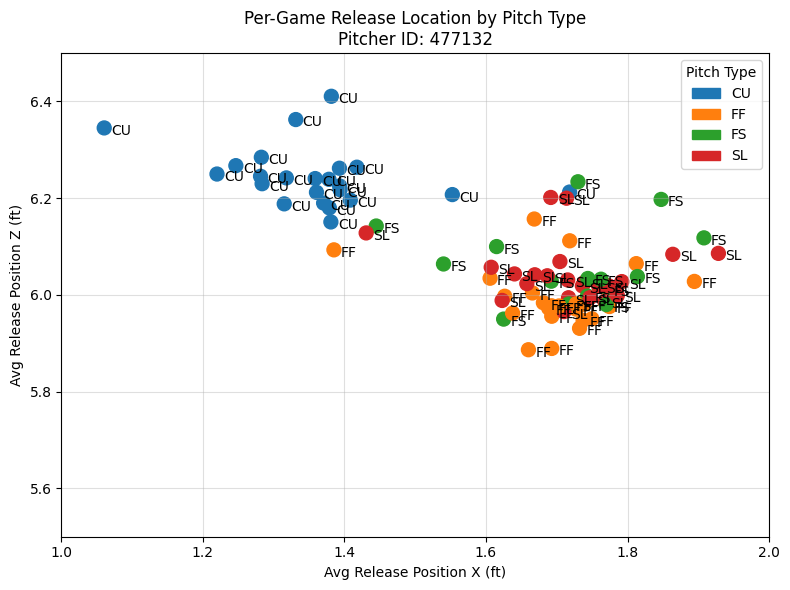

In [16]:
# Use the first pitcher in the dataset as an illustration
example_pitcher_id = pitcher_game_stats_df['pitcher_id'].iloc[0]
plot_df = pitcher_game_stats_df[
    pitcher_game_stats_df['pitcher_id'] == example_pitcher_id
].copy()

# Build a consistent color mapping for pitch types
unique_pitch_types = plot_df['pitch_type'].unique()
color_map = plt.get_cmap('tab10')
pitch_type_to_color = {pt: color_map(i % 10) for i, pt in enumerate(unique_pitch_types)}
colors = plot_df['pitch_type'].map(pitch_type_to_color)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_df['release_pos_x_mean'], plot_df['release_pos_z_mean'],
           s=100, c=colors)

for i, label in enumerate(plot_df['pitch_type']):
    ax.annotate(label,
                (plot_df['release_pos_x_mean'].iloc[i], plot_df['release_pos_z_mean'].iloc[i]),
                textcoords="offset points", xytext=(5, -5), ha='left', fontsize=10)

ax.set_xlabel('Avg Release Position X (ft)')
ax.set_ylabel('Avg Release Position Z (ft)')
ax.set_title(f'Per-Game Release Location by Pitch Type\nPitcher ID: {example_pitcher_id}')
ax.grid(True, alpha=0.4)
ax.set_xlim(1.0, 2.0)
ax.set_ylim(5.50, 6.50)

legend_handles = [
    mpatches.Patch(color=pitch_type_to_color[pt], label=pt)
    for pt in unique_pitch_types
]
ax.legend(handles=legend_handles, title='Pitch Type')
plt.tight_layout()
plt.show()

## 15. Visualization: Season-Average Release Position (Example Pitcher)

Collapse the per-game scatter by averaging over the full season.
Each point now represents the pitcher's typical release point for that pitch type.

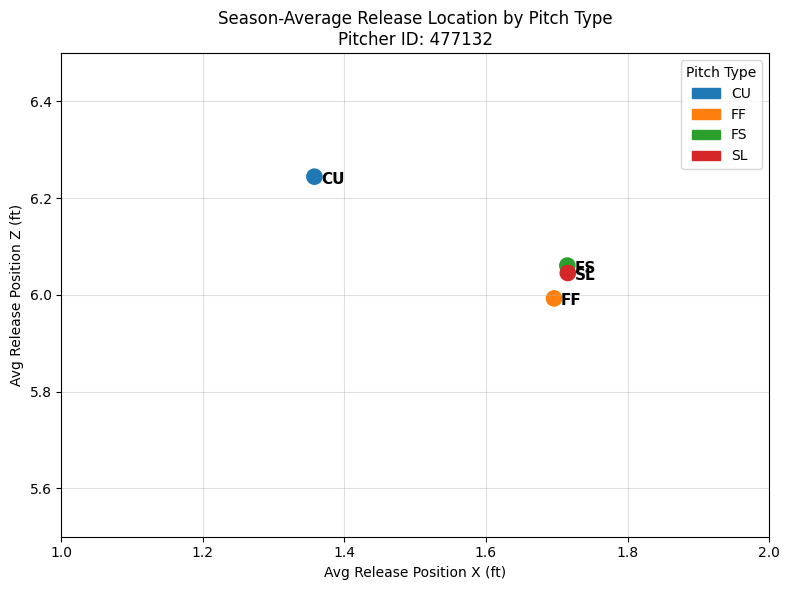

In [17]:
# Average release position per pitch type across all starts
avg_plot_df = (
    plot_df
    .groupby('pitch_type')
    .agg(
        release_pos_x_mean=('release_pos_x_mean', 'mean'),
        release_pos_z_mean=('release_pos_z_mean', 'mean'),
    )
    .reset_index()
)

avg_colors = avg_plot_df['pitch_type'].map(pitch_type_to_color)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(avg_plot_df['release_pos_x_mean'], avg_plot_df['release_pos_z_mean'],
           s=120, c=avg_colors)

for i, label in enumerate(avg_plot_df['pitch_type']):
    ax.annotate(label,
                (avg_plot_df['release_pos_x_mean'].iloc[i],
                 avg_plot_df['release_pos_z_mean'].iloc[i]),
                textcoords="offset points", xytext=(5, -5),
                ha='left', fontsize=11, fontweight='bold')

ax.set_xlabel('Avg Release Position X (ft)')
ax.set_ylabel('Avg Release Position Z (ft)')
ax.set_title(f'Season-Average Release Location by Pitch Type\nPitcher ID: {example_pitcher_id}')
ax.grid(True, alpha=0.4)
ax.set_xlim(1.0, 2.0)
ax.set_ylim(5.50, 6.50)
ax.legend(handles=legend_handles, title='Pitch Type')
plt.tight_layout()
plt.show()

## 16. Visualization: Pitch Type Usage Count (Clayton Kershaw)

Bar chart showing how many game starts Kershaw (ID 477132) used each pitch type,
based on the 5% minimum usage filter applied earlier.

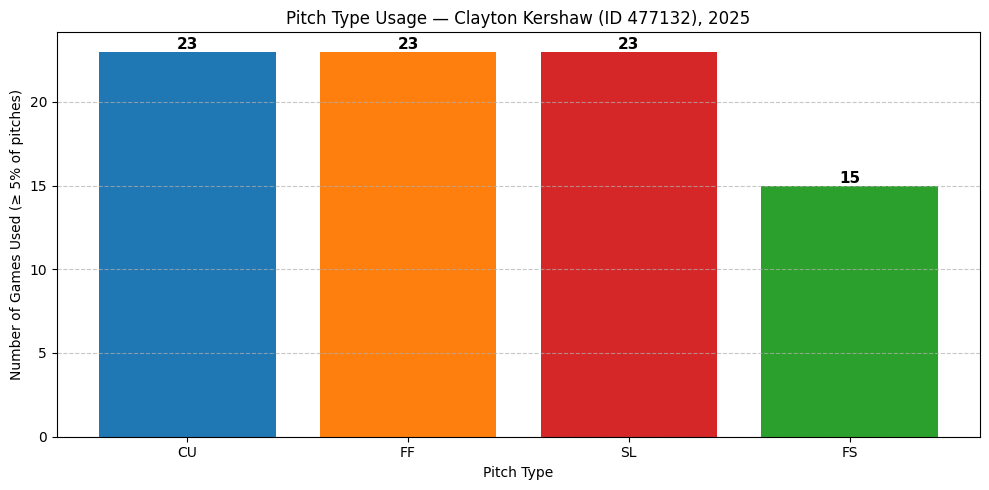

In [18]:
# Filter to Kershaw starts only
kershaw_id = 477132
kershaw_df = plot_df[plot_df['pitcher_id'] == kershaw_id]
pitch_type_counts = kershaw_df['pitch_type'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [pitch_type_to_color.get(pt, 'gray') for pt in pitch_type_counts.index]
bars = ax.bar(pitch_type_counts.index, pitch_type_counts.values, color=bar_colors)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_xlabel('Pitch Type')
ax.set_ylabel('Number of Games Used (≥ 5% of pitches)')
ax.set_title(f'Pitch Type Usage — Clayton Kershaw (ID {kershaw_id}), 2025')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Observation:** Kershaw's chart typically shows a 3–4 pitch arsenal (Four-seam, Slider, Curveball,
and occasionally a Sinker or Split-finger). The 5% threshold ensures we only capture pitch types
he intentionally uses in a given start rather than experimental or one-off offerings.

## 17. Demonstration: How `mean_release_pos_pairwise_distance` Is Calculated

For a single start (Kershaw, 2025-05-17), we visualise the pairwise distances between
all release-point means. Dotted lines connect each pair; each line is labelled with its
Euclidean distance.

The **total** of those distances divided by the number of pairs equals
`mean_release_pos_pairwise_distance` for that start.

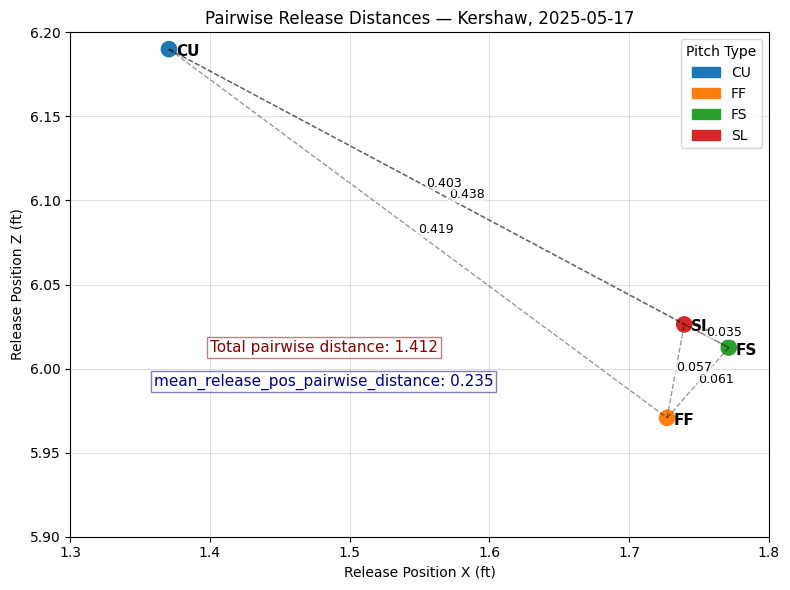

In [19]:
# Isolate a single start for illustration
subset_df = plot_df[
    (plot_df['pitcher_id'] == 477132) &
    (plot_df['game_date'] == '2025-05-17')
].copy()

subset_labels = subset_df['pitch_type']
subset_colors = subset_labels.map(pitch_type_to_color)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(subset_df['release_pos_x_mean'], subset_df['release_pos_z_mean'],
           s=120, c=subset_colors)

# Label each point with its pitch type
for i, label in enumerate(subset_labels):
    ax.annotate(label,
                (subset_df['release_pos_x_mean'].iloc[i],
                 subset_df['release_pos_z_mean'].iloc[i]),
                textcoords="offset points", xytext=(5, -5),
                ha='left', fontsize=11, fontweight='bold')

# Draw all pairwise connecting lines and label each with its distance
coords = list(zip(subset_df['release_pos_x_mean'], subset_df['release_pos_z_mean']))
total_distance = 0.0

for (i, (x1, y1)), (j, (x2, y2)) in itertools.combinations(enumerate(coords), 2):
    dist = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
    total_distance += dist

    ax.plot([x1, x2], [y1, y2], 'k--', alpha=0.4, linewidth=1)
    ax.text((x1 + x2) / 2, (y1 + y2) / 2, f"{dist:.3f}",
            fontsize=9, color='k',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1))

n_pairs = len(list(itertools.combinations(coords, 2)))
mean_distance = total_distance / n_pairs if n_pairs > 0 else np.nan

# Annotate summary stats on the plot
ax.text(1.4, 6.01, f"Total pairwise distance: {total_distance:.3f}",
        fontsize=11, color='darkred',
        bbox=dict(facecolor='white', edgecolor='darkred', alpha=0.5, pad=2))
ax.text(1.36, 5.99,
        f"mean_release_pos_pairwise_distance: {mean_distance:.3f}",
        fontsize=11, color='darkblue',
        bbox=dict(facecolor='white', edgecolor='darkblue', alpha=0.5, pad=2))

ax.set_xlabel('Release Position X (ft)')
ax.set_ylabel('Release Position Z (ft)')
ax.set_title('Pairwise Release Distances — Kershaw, 2025-05-17')
ax.grid(True, alpha=0.4)
ax.set_xlim(1.30, 1.80)
ax.set_ylim(5.90, 6.20)
ax.legend(handles=legend_handles, title='Pitch Type')
plt.tight_layout()
plt.show()

## 18. MLB Stats API — Helper Functions

Three functions wrap the official MLB Stats API to retrieve per-game pitching outcomes
for each SP. These are used later to merge traditional statistics (ERA, WHIP, Ks, BBs, HR)
with the Statcast tunneling data.

- **`get_pitcher_game_logs(player_id, season)`** — game-by-game stat splits
- **`get_pitcher_season_stats(player_id, season)`** — season aggregate stats
- **`get_player_info(player_id)`** — name and basic bio info

In [20]:
def get_pitcher_game_logs(player_id: int, season: int = 2025) -> Optional[pd.DataFrame]:
    """
    Retrieve game-by-game pitching statistics from the MLB Stats API.

    Args:
        player_id (int): MLBAM player ID.
        season (int): Season year (default 2025).

    Returns:
        pd.DataFrame | None: One row per game start with flattened stat columns,
                             or None on failure.
    """
    url = f"https://statsapi.mlb.com/api/v1/people/{player_id}/stats"
    params = {"stats": "gameLog", "group": "pitching", "season": str(season), "sportId": "1"}

    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()

        if not data.get('stats'):
            print(f"No game log data for player {player_id}.")
            return None

        game_logs = data['stats'][0]['splits']
        if not game_logs:
            return None

        df = pd.DataFrame(game_logs)

        # Flatten the nested 'stat' dict into individual columns
        if 'stat' in df.columns:
            stat_df = pd.json_normalize(df['stat'])
            df = pd.concat(
                [df[['date', 'opponent', 'team', 'isHome', 'game', 'season']], stat_df],
                axis=1
            )

        df['pitcher_id'] = player_id
        return df

    except requests.exceptions.RequestException as e:
        print(f"Request error for player {player_id}: {e}")
        return None
    except Exception as e:
        print(f"Unexpected error for player {player_id}: {e}")
        return None


def get_pitcher_season_stats(player_id: int, season: int = 2025) -> Optional[Dict]:
    """
    Retrieve season-aggregate pitching statistics from the MLB Stats API.

    Args:
        player_id (int): MLBAM player ID.
        season (int): Season year (default 2025).

    Returns:
        Dict | None: Flat dictionary of season-level stats, or None on failure.
    """
    url = f"https://statsapi.mlb.com/api/v1/people/{player_id}/stats"
    params = {"stats": "season", "group": "pitching", "season": str(season), "sportId": "1"}

    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()

        if not data.get('stats'):
            return None

        return data['stats'][0].get('stat')

    except requests.exceptions.RequestException as e:
        print(f"Request error for player {player_id}: {e}")
        return None


def get_player_info(player_id: int) -> Optional[Dict]:
    """
    Retrieve basic player information (name, position, team) from the MLB Stats API.

    Args:
        player_id (int): MLBAM player ID.

    Returns:
        Dict | None: Player bio dictionary, or None on failure.
    """
    url = f"https://statsapi.mlb.com/api/v1/people/{player_id}"

    try:
        response = requests.get(url)
        response.raise_for_status()
        return response.json()['people'][0]

    except requests.exceptions.RequestException as e:
        print(f"Request error for player {player_id}: {e}")
        return None


print("MLB Stats API helper functions defined.")

MLB Stats API helper functions defined.


## 19. Advanced Statistics Calculation Functions

### `calculate_advanced_stats(df)`
Derives rate-based pitching metrics from the raw counting stats returned by the
game log endpoint (ERA, WHIP, K/9, BB/9, HR/9, K/BB ratio, and a simplified
Game Score). Also flags quality starts (≥ 6 IP, ≤ 3 ER).

### `get_comprehensive_pitcher_data(player_id, season)`
Convenience wrapper that calls all three API helpers and returns a dictionary
containing `player_info`, `game_logs` (with advanced stats applied), and `season_stats`.

In [21]:
def calculate_advanced_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive advanced pitching metrics from basic game-log counting stats.

    New columns added:
        - opposing_batting_avg  : H / AB
        - walks_hits_per_inning : (BB + HBP + H) / IP  [WHIP variant]
        - era                   : (ER * 9) / IP
        - k_bb_ratio            : K / BB
        - k_per_9               : (K * 9) / IP
        - bb_per_9              : (BB * 9) / IP
        - hr_per_9              : (HR * 9) / IP
        - game_score            : simplified Thorn–Palmer game score
        - quality_start         : True if IP >= 6 and ER <= 3

    Args:
        df (pd.DataFrame): Game log DataFrame from get_pitcher_game_logs.

    Returns:
        pd.DataFrame: Same DataFrame with additional calculated columns.
    """
    df = df.copy()

    # Coerce relevant columns to numeric (API returns strings)
    numeric_cols = [
        'gamesPlayed', 'gamesStarted', 'completeGames', 'shutouts',
        'wins', 'losses', 'saves', 'inningsPitched', 'hits',
        'runs', 'earnedRuns', 'homeRuns', 'baseOnBalls', 'strikeOuts',
        'hitBatsmen', 'balks', 'wildPitches', 'pickoffs', 'atBats'
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    if 'hits' in df.columns and 'atBats' in df.columns:
        df['opposing_batting_avg'] = df['hits'] / df['atBats']

    if all(c in df.columns for c in ['baseOnBalls', 'hitBatsmen', 'hits', 'inningsPitched']):
        df['walks_hits_per_inning'] = (
            (df['baseOnBalls'] + df['hitBatsmen'] + df['hits']) / df['inningsPitched']
        )

    if 'earnedRuns' in df.columns and 'inningsPitched' in df.columns:
        df['era'] = (df['earnedRuns'] * 9) / df['inningsPitched']

    if 'strikeOuts' in df.columns and 'baseOnBalls' in df.columns:
        df['k_bb_ratio'] = (df['strikeOuts'] / df['baseOnBalls']).replace([np.inf, -np.inf], np.nan)

    if 'strikeOuts' in df.columns and 'inningsPitched' in df.columns:
        df['k_per_9'] = (df['strikeOuts'] * 9) / df['inningsPitched']

    if 'baseOnBalls' in df.columns and 'inningsPitched' in df.columns:
        df['bb_per_9'] = (df['baseOnBalls'] * 9) / df['inningsPitched']

    if 'homeRuns' in df.columns and 'inningsPitched' in df.columns:
        df['hr_per_9'] = (df['homeRuns'] * 9) / df['inningsPitched']

    # Simplified game score: 50 + (IP * 3) - H - (ER * 2) - BB + K
    game_score_cols = ['inningsPitched', 'hits', 'earnedRuns', 'baseOnBalls', 'strikeOuts']
    if all(c in df.columns for c in game_score_cols):
        df['game_score'] = (
            50
            + (df['inningsPitched'] * 3)
            - df['hits']
            - (df['earnedRuns'] * 2)
            - df['baseOnBalls']
            + df['strikeOuts']
        )

    # Quality start flag: pitcher goes at least 6 IP and allows 3 or fewer ER
    if 'inningsPitched' in df.columns and 'earnedRuns' in df.columns:
        df['quality_start'] = (df['inningsPitched'] >= 6) & (df['earnedRuns'] <= 3)

    return df


def get_comprehensive_pitcher_data(player_id: int, season: int = 2025) -> Optional[Dict]:
    """
    Fetch and combine game logs, season stats, and player bio for a single pitcher.

    Args:
        player_id (int): MLBAM player ID.
        season (int): Season year (default 2025).

    Returns:
        Dict with keys 'player_info', 'game_logs', 'season_stats', or None if player
        info cannot be retrieved.
    """
    player_info = get_player_info(player_id)
    if not player_info:
        print(f"Could not fetch player info for ID {player_id}. Skipping.")
        return None

    # Fetch and enrich game logs
    game_logs = get_pitcher_game_logs(player_id, season)
    if game_logs is not None and not game_logs.empty:
        game_logs = calculate_advanced_stats(game_logs)
    else:
        game_logs = None

    # Fetch season aggregate stats (handle edge cases)
    season_stats = None
    try:
        raw = get_pitcher_season_stats(player_id, season)
        if isinstance(raw, dict):
            season_stats = raw
        elif isinstance(raw, list) and raw and isinstance(raw[0], dict):
            season_stats = raw[0]
    except Exception as e:
        print(f"Error fetching season stats for player {player_id}: {e}")

    return {
        'player_info':  player_info,
        'game_logs':    game_logs,
        'season_stats': season_stats,
    }


print("Advanced statistics functions defined.")

Advanced statistics functions defined.


## 20. Example: Fetch and Inspect Data for a Single Pitcher (Kershaw)

Run this cell to verify the API functions work correctly before running the full batch.
Change `pitcher_id` to test any other SP.

In [22]:
pitcher_id = 477132  # Clayton Kershaw
season = 2025

pitcher_data = get_comprehensive_pitcher_data(pitcher_id, season)

if pitcher_data and pitcher_data['player_info']:
    info = pitcher_data['player_info']
    print(f"Player : {info.get('fullName', 'Unknown')}")
    print(f"Team   : {info.get('currentTeam', {}).get('name', 'Unknown')}")
    print(f"Position: {info.get('primaryPosition', {}).get('name', 'Unknown')}")

    logs = pitcher_data['game_logs']
    if logs is not None and not logs.empty:
        print(f"\nGame logs: {len(logs)} starts found in {season}")

        key_cols = [
            'date', 'inningsPitched', 'hits', 'earnedRuns',
            'baseOnBalls', 'strikeOuts', 'era', 'game_score', 'quality_start'
        ]
        display_cols = [c for c in key_cols if c in logs.columns]
        print(f"\nSample game log ({len(display_cols)} columns shown):")
        display(logs[display_cols].head(10))
    else:
        print(f"No game log data found for {season}.")

    if pitcher_data['season_stats']:
        print(f"\nSeason statistics available: {len(pitcher_data['season_stats'])} metrics")
    else:
        print(f"\nNo season statistics available for {season}.")
else:
    print(f"No data found for pitcher ID {pitcher_id}.")

Player : Clayton Kershaw
Team   : Unknown
Position: Pitcher

Game logs: 23 starts found in 2025

Sample game log (9 columns shown):


,date,inningsPitched,hits,earnedRuns,baseOnBalls,strikeOuts,era,game_score,quality_start
0,2025-05-17,4.0,5,5,3,2,11.250000,46.0,False
1,2025-05-23,2.0,0,0,1,1,0.000000,56.0,False
2,2025-05-28,5.0,6,1,2,3,1.800000,58.0,False
3,2025-06-03,4.2,6,3,3,2,6.428571,49.6,False
4,2025-06-08,5.0,6,1,0,7,1.800000,64.0,False
5,2025-06-14,7.0,3,0,1,5,0.000000,72.0,True
6,2025-06-20,5.0,5,2,2,4,3.600000,58.0,False
7,2025-06-26,6.0,2,1,1,5,1.500000,68.0,True
8,2025-07-02,6.0,9,4,1,3,6.000000,53.0,False
9,2025-07-08,6.0,6,2,1,3,3.000000,60.0,True



No season statistics available for 2025.


## 21. Batch Fetch Game Logs for All 2025 Starting Pitchers

⚠️ **This cell makes one API request per SP and can take several minutes.**

Results are stored in `sp_pitcher_data` — a dictionary keyed by MLBAM player ID,
where each value is the dict returned by `get_comprehensive_pitcher_data`.

In [23]:
sp_pitcher_data = {}

for each_pitcher in SP_2025_MLBIDs:
    data = get_comprehensive_pitcher_data(each_pitcher, season=2025)
    sp_pitcher_data[each_pitcher] = data

successful = sum(1 for d in sp_pitcher_data.values() if d is not None)
print(f"\nFetched data for {successful} / {len(SP_2025_MLBIDs)} starting pitchers.")

No game log data for player 502171.
No game log data for player 592826.
No game log data for player 605397.
No game log data for player 543037.
No game log data for player 548389.
No game log data for player 622072.
No game log data for player 607644.
No game log data for player 643290.
No game log data for player 656756.
No game log data for player 656818.
No game log data for player 657140.
No game log data for player 663556.
No game log data for player 663776.
No game log data for player 663959.
No game log data for player 665622.
No game log data for player 666129.
No game log data for player 666130.
No game log data for player 666159.
No game log data for player 666201.
No game log data for player 667498.
No game log data for player 668761.
No game log data for player 668766.
No game log data for player 668874.
No game log data for player 669165.
No game log data for player 669361.
No game log data for player 669370.
No game log data for player 669441.
No game log data for player 

## 22. Inspect `sp_pitcher_data` Structure

In [24]:
# Quick structural inspection of sp_pitcher_data
print(f"Type         : {type(sp_pitcher_data)}")
print(f"Total entries: {len(sp_pitcher_data)}")

first_id     = next(iter(sp_pitcher_data))
first_pitcher = sp_pitcher_data[first_id]

print(f"\nFirst pitcher ID : {first_id}")
print(f"Entry type       : {type(first_pitcher)}")

if isinstance(first_pitcher, dict):
    for key, value in first_pitcher.items():
        print(f"\n  Key: '{key}'")
        print(f"    Type: {type(value)}")

        if isinstance(value, pd.DataFrame):
            print(f"    Shape  : {value.shape}")
            print(f"    Columns: {list(value.columns)}")
            display(value.head(2))
        elif isinstance(value, dict):
            print(f"    Keys: {list(value.keys())}")
        elif isinstance(value, list):
            print(f"    Length: {len(value)}")
        else:
            print(f"    Preview: {str(value)[:120]}")

Type         : <class 'dict'>
Total entries: 366

First pitcher ID : 477132
Entry type       : <class 'dict'>

  Key: 'player_info'
    Type: <class 'dict'>
    Keys: ['id', 'fullName', 'link', 'firstName', 'lastName', 'primaryNumber', 'birthDate', 'currentAge', 'birthCity', 'birthStateProvince', 'birthCountry', 'height', 'weight', 'active', 'primaryPosition', 'useName', 'useLastName', 'middleName', 'boxscoreName', 'nickName', 'gender', 'isPlayer', 'isVerified', 'draftYear', 'lastPlayedDate', 'mlbDebutDate', 'batSide', 'pitchHand', 'nameFirstLast', 'nameSlug', 'firstLastName', 'lastFirstName', 'lastInitName', 'initLastName', 'fullFMLName', 'fullLFMName', 'strikeZoneTop', 'strikeZoneBottom']

  Key: 'game_logs'
    Type: <class 'pandas.core.frame.DataFrame'>
    Shape  : (23, 78)
    Columns: ['date', 'opponent', 'team', 'isHome', 'game', 'season', 'summary', 'gamesPlayed', 'gamesStarted', 'flyOuts', 'groundOuts', 'airOuts', 'runs', 'doubles', 'triples', 'homeRuns', 'strikeOuts', 'baseO

,date,opponent,team,isHome,game,season,summary,gamesPlayed,gamesStarted,flyOuts,groundOuts,airOuts,runs,doubles,triples,homeRuns,strikeOuts,baseOnBalls,intentionalWalks,hits,hitByPitch,avg,atBats,obp,slg,ops,caughtStealing,stolenBases,stolenBasePercentage,caughtStealingPercentage,groundIntoDoublePlay,numberOfPitches,era,inningsPitched,wins,losses,saves,saveOpportunities,holds,blownSaves,earnedRuns,whip,battersFaced,outs,gamesPitched,completeGames,shutouts,strikes,strikePercentage,hitBatsmen,balks,wildPitches,pickoffs,totalBases,groundOutsToAirouts,winPercentage,pitchesPerInning,gamesFinished,strikeoutWalkRatio,strikeoutsPer9Inn,walksPer9Inn,hitsPer9Inn,runsScoredPer9,homeRunsPer9,inheritedRunners,inheritedRunnersScored,catchersInterference,sacBunts,sacFlies,pitcher_id,opposing_batting_avg,walks_hits_per_inning,k_bb_ratio,k_per_9,bb_per_9,hr_per_9,game_score,quality_start
0,2025-05-17,"{'id': 108, 'name': 'Los Angeles Angels', 'link': '/api/v1/teams/108'}","{'id': 119, 'name': 'Los Angeles Dodgers', 'link': '/api/v1/teams/119'}",True,"{'gamePk': 777884, 'link': '/api/v1.1/game/777884/feed/live', 'content': {'link': '/api/v1/game/777884/content'}, 'gameNumber': 1, 'dayNight': 'day'}",2025,"4.0 IP, 5 ER, 2 K, 3 BB",1,1,3,4,6,5,2,0,1,2,3,0,5,0,.313,16,.400,.625,1.025,0,0,.---,.---,0,83,11.25,4.0,0,0,0,0,0,0,5,2.00,20,12,1,0,0,48,.580,0,0,0,0,10,0.67,.---,20.75,0,0.67,4.50,6.75,11.25,11.25,2.25,0,0,0,0,1,477132,0.3125,2.0,0.666667,4.5,6.75,2.25,46.0,False
1,2025-05-23,"{'id': 121, 'name': 'New York Mets', 'link': '/api/v1/teams/121'}","{'id': 119, 'name': 'Los Angeles Dodgers', 'link': '/api/v1/teams/119'}",False,"{'gamePk': 777808, 'link': '/api/v1.1/game/777808/feed/live', 'content': {'link': '/api/v1/game/777808/content'}, 'gameNumber': 1, 'dayNight': 'day'}",2025,"2.0 IP, 0 ER, K, BB",1,1,1,3,1,0,0,0,0,1,1,0,0,0,.238,5,.167,.000,.167,0,0,.---,.---,1,26,0.00,2.0,0,0,0,0,0,0,0,1.50,6,6,1,0,0,14,.540,0,0,0,0,0,1.00,.---,13.00,0,1.00,4.50,4.50,0.00,0.00,0.00,0,0,0,0,0,477132,0.0000,0.5,1.000000,4.5,4.50,0.00,56.0,False



  Key: 'season_stats'
    Type: <class 'NoneType'>
    Preview: None


In [25]:
# Remove any game logs in sp_pitcher_data where inningsPitched == 0
for pid, pitcher_info in sp_pitcher_data.items():
    if isinstance(pitcher_info, dict):
        game_logs = pitcher_info.get('game_logs')
        if isinstance(game_logs, pd.DataFrame) and 'inningsPitched' in game_logs.columns:
            # Remove rows where inningsPitched == 0 or inningsPitched is NaN
            filtered_logs = game_logs[game_logs['inningsPitched'].fillna(0) != 0].copy()
            sp_pitcher_data[pid]['game_logs'] = filtered_logs

In [26]:
# Summary statistics for all values of homeRunsPer9 from each pitcher in the 2025 season
# Also check for any non-numeric or non-float values encountered

all_home_runs_per_9 = []

for pid, pitcher_info in sp_pitcher_data.items():
    if not isinstance(pitcher_info, dict):
        continue
    game_logs = pitcher_info.get('game_logs')
    if not isinstance(game_logs, pd.DataFrame) or game_logs.empty:
        continue
    # Try several common spellings/cases for the home runs per 9 column
    hr9_candidates = [
        'homeRunsPer9', 'home_runs_per_9', 'hr_per_9', 'hrPer9', 'homeRunsPerNine'
    ]
    found = False
    for col in hr9_candidates:
        if col in game_logs.columns:
            all_home_runs_per_9.extend(game_logs[col].dropna().tolist())
            found = True
            break
    if not found:
        print(f"Warning: Couldn't find home runs per 9 column for pitcher {pid}")

if all_home_runs_per_9:
    # Now check for non-numeric types
    non_numeric = [v for v in all_home_runs_per_9 if not isinstance(v, (int, float, np.integer, np.floating))]
    print(f"Number of homeRunsPer9 values: {len(all_home_runs_per_9)}")
    if non_numeric:
        print(f"Non-numeric homeRunsPer9 values encountered: {non_numeric}")
        # Try converting all to floats (will error/warn if not castable!)
        try:
            hr9_floats = [float(v) for v in all_home_runs_per_9]
        except Exception as e:
            print("Error converting some values to float:", e)
            hr9_floats = []
    else:
        hr9_floats = all_home_runs_per_9

    if hr9_floats:
        hr9_series = pd.Series(hr9_floats)
        print("Home Runs Per 9 (All Pitchers, 2025):")
        print(hr9_series.describe())
    else:
        print("No valid float homeRunsPer9 data found.")
else:
    print("No homeRunsPer9 data found for any pitcher in 2025 season.")

# Convert all non-numeric homeRunsPer9 values to floats if possible (e.g., replace '-.--' with np.nan)
def clean_home_runs_per_9(values):
    cleaned = []
    for v in values:
        if isinstance(v, (int, float, np.integer, np.floating)):
            cleaned.append(float(v))
        else:
            try:
                if str(v).strip() in {"-.-", "-.--", "--"}:
                    cleaned.append(np.nan)
                else:
                    cleaned.append(float(v))
            except Exception:
                # Could not parse; replace with NaN for consistency
                cleaned.append(np.nan)
    return cleaned

all_home_runs_per_9_cleaned = clean_home_runs_per_9(all_home_runs_per_9)
print("All homeRunsPer9 values coerced to floats (with non-numeric replaced by NaN):")
print(pd.Series(all_home_runs_per_9_cleaned).describe())

Number of homeRunsPer9 values: 5667
Non-numeric homeRunsPer9 values encountered: ['2.25', '0.00', '0.00', '1.93', '0.00', '0.00', '3.60', '1.50', '1.50', '0.00', '0.00', '0.00', '0.00', '0.00', '1.50', '0.00', '0.00', '0.00', '0.00', '0.00', '2.08', '0.00', '0.00', '6.00', '0.00', '1.80', '0.00', '3.00', '3.60', '1.29', '1.50', '1.50', '1.29', '0.00', '3.00', '4.50', '2.08', '0.00', '27.00', '1.80', '0.00', '3.60', '1.80', '1.80', '3.86', '2.45', '0.00', '9.00', '2.25', '0.00', '3.00', '0.00', '1.50', '0.00', '0.00', '0.00', '0.00', '0.00', '1.69', '0.00', '3.38', '2.70', '1.50', '0.00', '4.15', '0.00', '1.50', '1.80', '2.45', '3.00', '0.00', '6.75', '0.00', '4.50', '0.00', '6.23', '1.80', '0.00', '0.00', '5.40', '0.00', '1.50', '1.59', '4.50', '0.00', '0.00', '0.00', '3.00', '0.00', '0.00', '0.00', '1.50', '4.50', '1.35', '2.45', '1.80', '3.86', '0.00', '1.59', '1.50', '0.00', '1.42', '1.80', '3.00', '0.00', '1.93', '0.00', '0.00', '0.00', '1.50', '0.00', '0.00', '1.80', '0.00', '1.80

## 23. Merge Statcast Release Data with MLB Stats API Game Logs

Combines `pitcher_game_stats_df` (release position tunneling metrics from Statcast)
with `sp_pitcher_data` (per-game outcome stats from the MLB Stats API) on
`pitcher_id` and `game_date`.

Steps:
1. Extract each pitcher's `game_logs` DataFrame from `sp_pitcher_data` and standardise
   the date column name to `game_date`.
2. Concatenate all game logs into `merged_sp_game_logs_df`.
3. Merge left onto `pitcher_game_stats_df`.

## PROBABLY NEED TO CHANGE THIS BELOW TO MERGE TO JUST THE EVENTS IN THE TWO largest_distance DATAFRAMES.

In [27]:
def flatten_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """Collapse a MultiIndex column header to single-level using '_' as separator."""
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = ['_'.join(str(l) for l in col if l) for col in df.columns]
    return df


# ── Step 1: Collect all game log DataFrames ───────────────────────────────────
sp_game_logs_list = []

for pid, pitcher_info in sp_pitcher_data.items():
    if not isinstance(pitcher_info, dict):
        continue
    game_logs = pitcher_info.get('game_logs')
    if not isinstance(game_logs, pd.DataFrame) or game_logs.empty:
        continue

    df_gl = game_logs.copy()
    df_gl['pitcher_id'] = pid

    # Standardise the date column name to 'game_date'
    if 'game_date' not in df_gl.columns:
        if 'date' in df_gl.columns:
            df_gl['game_date'] = df_gl['date']
        else:
            continue  # Cannot merge without a date key

    sp_game_logs_list.append(df_gl)

merged_sp_game_logs_df = (
    pd.concat(sp_game_logs_list, ignore_index=True)
    if sp_game_logs_list else pd.DataFrame()
)
print(f"Combined game logs: {merged_sp_game_logs_df.shape}")

# ── Step 2: Flatten MultiIndex columns if present ─────────────────────────────
#pitcher_game_stats_df = flatten_column_names(pitcher_game_stats_df)
# We can try this later. For now, we will just try using pitch_with_largest_distance


# ── Step 3: Locate pitcher_id and game_date columns dynamically ───────────────
id_col   = next((c for c in pitch_with_largest_distance.columns if 'id'   in c.lower()), None)
date_col = next((c for c in pitch_with_largest_distance.columns if 'date' in c.lower()), None)

if not merged_sp_game_logs_df.empty and id_col and date_col:
    # Align dtypes for join keys
    merged_sp_game_logs_df['pitcher_id'] = merged_sp_game_logs_df['pitcher_id'].astype(str)
    merged_sp_game_logs_df['game_date']  = pd.to_datetime(merged_sp_game_logs_df['game_date'])
    pitch_with_largest_distance[id_col]   = pitch_with_largest_distance[id_col].astype(str)
    pitch_with_largest_distance[date_col] = pd.to_datetime(pitch_with_largest_distance[date_col])

    # Drop overlapping non-key columns from the right table to avoid _spgl suffixes
    shared_cols = (
    set(merged_sp_game_logs_df.columns)
    & set(pitch_with_largest_distance.columns)
) - {'pitcher_id', 'game_date'}

    right_cols = [c for c in merged_sp_game_logs_df.columns if c not in shared_cols]

    merged_largest_distance = pd.merge(
        pitch_with_largest_distance,
        merged_sp_game_logs_df[right_cols],
        left_on=[id_col, date_col],
        right_on=['pitcher_id', 'game_date'],
        how='left',
        suffixes=('', '_spgl')
    )
else:
    merged_largest_distance = pitch_with_largest_distance.copy()
    print("Warning: Merge skipped — check sp_pitcher_data and pitch_with_largest_distance formats.")

print(f"merged_largest_distance shape after join: {merged_largest_distance.shape}")

Combined game logs: (5667, 79)
merged_largest_distance shape after join: (5671, 97)


In [28]:
merged_largest_distance.head(3)

,pitcher_id,game_date,pitch_type,release_speed_mean,release_speed_std,release_pos_x_mean,release_pos_x_std,release_pos_z_mean,release_pos_z_std,arm_angle_mean,arm_angle_std,mean_release_pos_pairwise_distance,total_release_pos_pairwise_distance,pitch_specific_distance,expected_distance_proportion,actual_distance_proportion,avg_pitch_x,avg_pitch_z,euc_distance_from_centroid,pitch_specific_distance_rank,date,opponent,team,isHome,game,season,summary,gamesPlayed,gamesStarted,flyOuts,groundOuts,airOuts,runs,doubles,triples,homeRuns,strikeOuts,baseOnBalls,intentionalWalks,hits,hitByPitch,avg,atBats,obp,slg,ops,caughtStealing,stolenBases,stolenBasePercentage,caughtStealingPercentage,groundIntoDoublePlay,numberOfPitches,era,inningsPitched,wins,losses,saves,saveOpportunities,holds,blownSaves,earnedRuns,whip,battersFaced,outs,gamesPitched,completeGames,shutouts,strikes,strikePercentage,hitBatsmen,balks,wildPitches,pickoffs,totalBases,groundOutsToAirouts,winPercentage,pitchesPerInning,gamesFinished,strikeoutWalkRatio,strikeoutsPer9Inn,walksPer9Inn,hitsPer9Inn,runsScoredPer9,homeRunsPer9,inheritedRunners,inheritedRunnersScored,catchersInterference,sacBunts,sacFlies,opposing_batting_avg,walks_hits_per_inning,k_bb_ratio,k_per_9,bb_per_9,hr_per_9,game_score,quality_start
0,506433,2025-09-02,CU,70.466667,1.988634,-1.900000,0.157734,5.656667,0.081158,44.216667,3.156211,0.445308,9.351465,7.102809,0.142857,0.379770,-2.753327,5.109648,1.013606,1,2025-09-02,"{'id': 110, 'name': 'Baltimore Orioles', 'link': '/api/v1/teams/110'}","{'id': 135, 'name': 'San Diego Padres', 'link': '/api/v1/teams/135'}",True,"{'gamePk': 776480, 'link': '/api/v1.1/game/776480/feed/live', 'content': {'link': '/api/v1/game/776480/content'}, 'gameNumber': 1, 'dayNight': 'day'}",2025,"4.0 IP, 3 ER, 6 K, 2 BB",1.0,1.0,2.0,1.0,3.0,4.0,1.0,0.0,1.0,6.0,2.0,0.0,6.0,2.0,.230,16.0,.500,.625,1.125,1.0,1.0,.500,.500,0.0,87.0,6.750000,4.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,1.18,20.0,12.0,1.0,0.0,0.0,59.0,.680,2.0,0.0,0.0,0.0,10.0,0.79,.000,21.75,0.0,3.00,13.50,4.50,13.50,9.00,2.25,0.0,0.0,0.0,0.0,0.0,0.375000,2.500000,3.0,13.500000,4.5,2.25,54.0,False
1,506433,2025-09-20,CU,69.160000,1.503477,-1.178000,0.160194,5.737000,0.065836,43.190000,2.592489,0.414555,8.705646,6.805854,0.142857,0.390887,-2.004253,5.226138,0.971428,2,2025-09-20,"{'id': 145, 'name': 'Chicago White Sox', 'link': '/api/v1/teams/145'}","{'id': 135, 'name': 'San Diego Padres', 'link': '/api/v1/teams/135'}",False,"{'gamePk': 776250, 'link': '/api/v1.1/game/776250/feed/live', 'content': {'link': '/api/v1/game/776250/content'}, 'gameNumber': 1, 'dayNight': 'day'}",2025,"4.2 IP, 2 ER, 4 K, 0 BB",1.0,1.0,1.0,5.0,4.0,2.0,2.0,0.0,0.0,4.0,0.0,0.0,6.0,0.0,.239,18.0,.333,.444,.777,0.0,0.0,.---,.---,1.0,78.0,4.285714,4.2,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.15,19.0,14.0,1.0,0.0,0.0,55.0,.710,0.0,0.0,0.0,0.0,8.0,0.87,.---,16.71,0.0,-.--,7.71,0.00,11.57,3.86,0.00,0.0,0.0,0.0,1.0,0.0,0.333333,1.428571,NaN,8.571429,0.0,0.00,56.6,False
2,506433,2025-08-17,CU,71.508333,1.503002,-1.805833,0.181782,5.547500,0.082255,45.666667,3.532018,0.434909,9.133098,6.130442,0.142857,0.335617,-2.602751,5.185802,0.875159,3,2025-08-17,"{'id': 119, 'name': 'Los Angeles Dodgers', 'link': '/api/v1/teams/119'}","{'id': 135, 'name': 'San Diego Padres', 'link': '/api/v1/teams/135'}",False,"{'gamePk': 776697, 'link': '/api/v1.1/game/776697/feed/live', 'content': {'link': '/api/v1/game/776697/content'}, 'gameNumber': 1, 'dayNight': 'day'}",2025,"4.0 IP, 4 ER, 5 K, 2 BB",1.0,1.0,3.0,1.0,6.0,4.0,0.0,0.0,2.0,5.0,2.0,0.0,3.0,0.0,.234,15.0,.294,.600,.894,0.0,1.0,1.000,.000,0.0,82.0,9.000000,4.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.22,17.0,12.0,1.0,0.0,0.0,52.0,.630,0.0,0.0,0.0,0.0,9.0,0.83,.---,20.50,0.0,2.50,11.25,4.50,6.75,9.00,4.50,0.0,0.0,0.0,0.0,0.0,0.200000,1.250000,2.5,11.250000,4.5,4.50,54.0,False


In [29]:
def flatten_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """Collapse a MultiIndex column header to single-level using '_' as separator."""
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = ['_'.join(str(l) for l in col if l) for col in df.columns]
    return df


# ── Step 1: Collect all game log DataFrames ───────────────────────────────────
sp_game_logs_list = []

for pid, pitcher_info in sp_pitcher_data.items():
    if not isinstance(pitcher_info, dict):
        continue
    game_logs = pitcher_info.get('game_logs')
    if not isinstance(game_logs, pd.DataFrame) or game_logs.empty:
        continue

    df_gl = game_logs.copy()
    df_gl['pitcher_id'] = pid

    # Standardise the date column name to 'game_date'
    if 'game_date' not in df_gl.columns:
        if 'date' in df_gl.columns:
            df_gl['game_date'] = df_gl['date']
        else:
            continue  # Cannot merge without a date key

    sp_game_logs_list.append(df_gl)

merged_sp_game_logs_df = (
    pd.concat(sp_game_logs_list, ignore_index=True)
    if sp_game_logs_list else pd.DataFrame()
)
print(f"Combined game logs: {merged_sp_game_logs_df.shape}")

# ── Step 2: Flatten MultiIndex columns if present ─────────────────────────────
#pitcher_game_stats_df = flatten_column_names(pitcher_game_stats_df)
# We can try this later. For now, we will just try using pitch_with_largest_distance_centroid


# ── Step 3: Locate pitcher_id and game_date columns dynamically ───────────────
id_col   = next((c for c in pitch_with_largest_distance_centroid.columns if 'id'   in c.lower()), None)
date_col = next((c for c in pitch_with_largest_distance_centroid.columns if 'date' in c.lower()), None)

if not merged_sp_game_logs_df.empty and id_col and date_col:
    # Align dtypes for join keys
    merged_sp_game_logs_df['pitcher_id'] = merged_sp_game_logs_df['pitcher_id'].astype(str)
    merged_sp_game_logs_df['game_date']  = pd.to_datetime(merged_sp_game_logs_df['game_date'])
    pitch_with_largest_distance_centroid[id_col]   = pitch_with_largest_distance_centroid[id_col].astype(str)
    pitch_with_largest_distance_centroid[date_col] = pd.to_datetime(pitch_with_largest_distance_centroid[date_col])

    # Drop overlapping non-key columns from the right table to avoid _spgl suffixes
    shared_cols = (
    set(merged_sp_game_logs_df.columns)
    & set(pitch_with_largest_distance_centroid.columns)
) - {'pitcher_id', 'game_date'}

    right_cols = [c for c in merged_sp_game_logs_df.columns if c not in shared_cols]

    merged_largest_distance_centroid = pd.merge(
        pitch_with_largest_distance_centroid,
        merged_sp_game_logs_df[right_cols],
        left_on=[id_col, date_col],
        right_on=['pitcher_id', 'game_date'],
        how='left',
        suffixes=('', '_spgl')
    )
else:
    merged_largest_distance_centroid = pitch_with_largest_distance_centroid.copy()
    print("Warning: Merge skipped — check sp_pitcher_data and pitch_with_largest_distance_centroid formats.")

print(f"merged_largest_distance_centroid shape after join: {merged_largest_distance_centroid.shape}")

Combined game logs: (5667, 79)
merged_largest_distance_centroid shape after join: (5671, 97)


In [30]:
merged_largest_distance_centroid.head(3)

,pitcher_id,game_date,pitch_type,release_speed_mean,release_speed_std,release_pos_x_mean,release_pos_x_std,release_pos_z_mean,release_pos_z_std,arm_angle_mean,arm_angle_std,mean_release_pos_pairwise_distance,total_release_pos_pairwise_distance,pitch_specific_distance,expected_distance_proportion,actual_distance_proportion,avg_pitch_x,avg_pitch_z,euc_distance_from_centroid,euc_distance_from_mean_rank,date,opponent,team,isHome,game,season,summary,gamesPlayed,gamesStarted,flyOuts,groundOuts,airOuts,runs,doubles,triples,homeRuns,strikeOuts,baseOnBalls,intentionalWalks,hits,hitByPitch,avg,atBats,obp,slg,ops,caughtStealing,stolenBases,stolenBasePercentage,caughtStealingPercentage,groundIntoDoublePlay,numberOfPitches,era,inningsPitched,wins,losses,saves,saveOpportunities,holds,blownSaves,earnedRuns,whip,battersFaced,outs,gamesPitched,completeGames,shutouts,strikes,strikePercentage,hitBatsmen,balks,wildPitches,pickoffs,totalBases,groundOutsToAirouts,winPercentage,pitchesPerInning,gamesFinished,strikeoutWalkRatio,strikeoutsPer9Inn,walksPer9Inn,hitsPer9Inn,runsScoredPer9,homeRunsPer9,inheritedRunners,inheritedRunnersScored,catchersInterference,sacBunts,sacFlies,opposing_batting_avg,walks_hits_per_inning,k_bb_ratio,k_per_9,bb_per_9,hr_per_9,game_score,quality_start
0,542881,2025-08-16,SL,79.850000,0.929157,2.5025,0.203204,4.937500,0.224852,14.80,4.907817,1.130175,6.781048,5.658535,0.25,0.417232,1.477619,5.911934,1.414179,1,2025-08-16,"{'id': 133, 'name': 'Athletics', 'link': '/api/v1/teams/133'}","{'id': 108, 'name': 'Los Angeles Angels', 'link': '/api/v1/teams/108'}",False,"{'gamePk': 776718, 'link': '/api/v1.1/game/776718/feed/live', 'content': {'link': '/api/v1/game/776718/content'}, 'gameNumber': 1, 'dayNight': 'day'}",2025,"4.0 IP, 4 ER, K, 5 BB",1.0,1.0,3.0,3.0,7.0,4.0,0.0,0.0,1.0,1.0,5.0,0.0,3.0,0.0,.256,14.0,.421,.429,.850,0.0,0.0,.---,.---,1.0,85.0,9.000000,4.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,1.42,19.0,12.0,1.0,0.0,0.0,44.0,.520,0.0,0.0,0.0,0.0,6.0,0.56,.000,21.25,0.0,0.20,2.25,11.25,6.75,9.00,2.25,0.0,0.0,0.0,0.0,0.0,0.214286,2.000000,0.2,2.25,11.250000,2.250000,47.0,False
1,542881,2025-05-22,SI,87.025000,0.708872,2.6275,0.103722,5.405000,0.220378,20.15,2.212841,0.951468,5.708806,4.781939,0.25,0.418821,1.664164,6.112127,1.195009,2,2025-05-22,"{'id': 133, 'name': 'Athletics', 'link': '/api/v1/teams/133'}","{'id': 108, 'name': 'Los Angeles Angels', 'link': '/api/v1/teams/108'}",False,"{'gamePk': 777812, 'link': '/api/v1.1/game/777812/feed/live', 'content': {'link': '/api/v1/game/777812/content'}, 'gameNumber': 1, 'dayNight': 'day'}",2025,"4.2 IP, 5 ER, 0 K, 6 BB",1.0,1.0,4.0,5.0,8.0,5.0,1.0,0.0,1.0,0.0,6.0,0.0,7.0,0.0,.217,19.0,.500,.579,1.079,0.0,0.0,.---,.---,0.0,99.0,10.714286,4.2,0.0,0.0,0.0,0.0,0.0,0.0,5.0,1.24,26.0,14.0,1.0,0.0,0.0,55.0,.560,0.0,0.0,0.0,0.0,11.0,0.58,.---,21.21,0.0,0.00,0.00,11.57,13.50,9.64,1.93,0.0,0.0,0.0,0.0,1.0,0.368421,3.095238,0.0,0.00,12.857143,2.142857,39.6,False
2,542881,2025-08-06,SI,89.066667,1.365040,2.5500,0.144222,5.366667,0.180093,22.90,4.095119,0.877408,5.264450,4.566936,0.25,0.433752,1.641923,6.057983,1.141281,3,2025-08-06,"{'id': 139, 'name': 'Tampa Bay Rays', 'link': '/api/v1/teams/139'}","{'id': 108, 'name': 'Los Angeles Angels', 'link': '/api/v1/teams/108'}",True,"{'gamePk': 776843, 'link': '/api/v1.1/game/776843/feed/live', 'content': {'link': '/api/v1/game/776843/content'}, 'gameNumber': 1, 'dayNight': 'day'}",2025,"4.0 IP, 4 ER, 5 K, BB",1.0,1.0,0.0,2.0,5.0,4.0,0.0,0.0,3.0,5.0,1.0,0.0,5.0,0.0,.257,17.0,.333,.824,1.157,0.0,0.0,.---,.---,0.0,69.0,9.000000,4.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.40,18.0,12.0,1.0,0.0,0.0,49.0,.710,0.0,1.0,0.0,0.0,14.0,0.57,.---,17.25,0.0,5.00,11.25,2.25,11.25,9.00,6.75,0.0,0.0,0.0,0.0,0.0,0.294118,1.500000,5.0,11.25,2.250000,6.750000,53.0,False


In [31]:
# Get summary statistics for the specified columns from pitch_with_largest_distance
cols_for_stats = [
    "euc_distance_from_mean",
    "mean_release_pos_pairwise_distance",
    "total_release_pos_pairwise_distance",
    "pitch_specific_distance",
    "expected_distance_proportion",
    "actual_distance_proportion"
]

# Only keep columns that actually exist in pitch_with_largest_distance
stats_cols_present = [col for col in cols_for_stats if col in merged_largest_distance.columns]

# Describe and show
summary_stats = pitch_with_largest_distance[stats_cols_present].describe()
print(summary_stats)

       mean_release_pos_pairwise_distance  \
count                         5671.000000   
mean                             0.205537   
std                              0.098622   
min                              0.019072   
25%                              0.138712   
50%                              0.187337   
75%                              0.252502   
max                              1.130175   

       total_release_pos_pairwise_distance  pitch_specific_distance  \
count                          5671.000000              5671.000000   
mean                              1.636555                 0.970956   
std                               1.191957                 0.629809   
min                               0.033559                 0.033559   
25%                               0.845577                 0.555695   
50%                               1.368953                 0.833776   
75%                               2.103705                 1.231164   
max                       

In [32]:
# Get summary statistics for the specified columns from pitch_with_largest_distance_centroid
cols_for_stats = [
    "euc_distance_from_mean",
    "mean_release_pos_pairwise_distance",
    "total_release_pos_pairwise_distance",
    "pitch_specific_distance",
    "expected_distance_proportion",
    "actual_distance_proportion"
]

# Only keep columns that actually exist in pitch_with_largest_distance
stats_cols_present = [col for col in cols_for_stats if col in pitch_with_largest_distance_centroid.columns]

# Describe and show
summary_stats_centroid = merged_largest_distance_centroid[stats_cols_present].describe()
print(summary_stats_centroid)

       mean_release_pos_pairwise_distance  \
count                         5671.000000   
mean                             0.205537   
std                              0.098622   
min                              0.019072   
25%                              0.138712   
50%                              0.187337   
75%                              0.252502   
max                              1.130175   

       total_release_pos_pairwise_distance  pitch_specific_distance  \
count                          5671.000000              5671.000000   
mean                              1.636555                 0.970733   
std                               1.191957                 0.629819   
min                               0.033559                 0.033559   
25%                               0.845577                 0.555695   
50%                               1.368953                 0.833776   
75%                               2.103705                 1.230939   
max                       

## 24. Drop Irrelevant Columns

Remove columns that are not useful for tunneling analysis — primarily roster/transaction
fields returned by the API that have no bearing on pitch release or game outcomes.

In [33]:
cols_to_drop = [
    'opponent', 'team', 'game', 'season',
    'gamesPlayed', 'stolenBases', 'caughtStealing',
    'stolenBasePercentage', 'caughtStealingPercentage',
    'saves', 'saveOpportunities', 'holds', 'blownSaves',
    'gamesPitched', 'balks', 'pickoffs', 'winPercentage',
    'gamesFinished', 'inheritedRunners', 'inheritedRunnersScored',
    'catchersinterference'
]

pitch_with_largest_distance = merged_largest_distance.drop(
    columns=[c for c in cols_to_drop if c in merged_largest_distance.columns]
)

pitch_with_largest_distance_centroid = merged_largest_distance_centroid.drop(
    columns=[c for c in cols_to_drop if c in merged_largest_distance_centroid.columns]
)

print(f"Columns remaining: {pitch_with_largest_distance.shape[1]}")
pitch_with_largest_distance.head(5)

print(f"Columns remaining: {pitch_with_largest_distance_centroid.shape[1]}")
pitch_with_largest_distance_centroid.head(5)

Columns remaining: 77
Columns remaining: 77


,pitcher_id,game_date,pitch_type,release_speed_mean,release_speed_std,release_pos_x_mean,release_pos_x_std,release_pos_z_mean,release_pos_z_std,arm_angle_mean,arm_angle_std,mean_release_pos_pairwise_distance,total_release_pos_pairwise_distance,pitch_specific_distance,expected_distance_proportion,actual_distance_proportion,avg_pitch_x,avg_pitch_z,euc_distance_from_centroid,euc_distance_from_mean_rank,date,isHome,summary,gamesStarted,flyOuts,groundOuts,airOuts,runs,doubles,triples,homeRuns,strikeOuts,baseOnBalls,intentionalWalks,hits,hitByPitch,avg,atBats,obp,slg,ops,groundIntoDoublePlay,numberOfPitches,era,inningsPitched,wins,losses,earnedRuns,whip,battersFaced,outs,completeGames,shutouts,strikes,strikePercentage,hitBatsmen,wildPitches,totalBases,groundOutsToAirouts,pitchesPerInning,strikeoutWalkRatio,strikeoutsPer9Inn,walksPer9Inn,hitsPer9Inn,runsScoredPer9,homeRunsPer9,catchersInterference,sacBunts,sacFlies,opposing_batting_avg,walks_hits_per_inning,k_bb_ratio,k_per_9,bb_per_9,hr_per_9,game_score,quality_start
0,542881,2025-08-16,SL,79.850000,0.929157,2.5025,0.203204,4.937500,0.224852,14.800000,4.907817,1.130175,6.781048,5.658535,0.250000,0.417232,1.477619,5.911934,1.414179,1,2025-08-16,False,"4.0 IP, 4 ER, K, 5 BB",1.0,3.0,3.0,7.0,4.0,0.0,0.0,1.0,1.0,5.0,0.0,3.0,0.0,.256,14.0,.421,.429,.850,1.0,85.0,9.000000,4.0,0.0,1.0,4.0,1.42,19.0,12.0,0.0,0.0,44.0,.520,0.0,0.0,6.0,0.56,21.25,0.20,2.25,11.25,6.75,9.00,2.25,0.0,0.0,0.0,0.214286,2.000000,0.2,2.25,11.250000,2.250000,47.0,False
1,542881,2025-05-22,SI,87.025000,0.708872,2.6275,0.103722,5.405000,0.220378,20.150000,2.212841,0.951468,5.708806,4.781939,0.250000,0.418821,1.664164,6.112127,1.195009,2,2025-05-22,False,"4.2 IP, 5 ER, 0 K, 6 BB",1.0,4.0,5.0,8.0,5.0,1.0,0.0,1.0,0.0,6.0,0.0,7.0,0.0,.217,19.0,.500,.579,1.079,0.0,99.0,10.714286,4.2,0.0,0.0,5.0,1.24,26.0,14.0,0.0,0.0,55.0,.560,0.0,0.0,11.0,0.58,21.21,0.00,0.00,11.57,13.50,9.64,1.93,0.0,0.0,1.0,0.368421,3.095238,0.0,0.00,12.857143,2.142857,39.6,False
2,542881,2025-08-06,SI,89.066667,1.365040,2.5500,0.144222,5.366667,0.180093,22.900000,4.095119,0.877408,5.264450,4.566936,0.250000,0.433752,1.641923,6.057983,1.141281,3,2025-08-06,True,"4.0 IP, 4 ER, 5 K, BB",1.0,0.0,2.0,5.0,4.0,0.0,0.0,3.0,5.0,1.0,0.0,5.0,0.0,.257,17.0,.333,.824,1.157,0.0,69.0,9.000000,4.0,0.0,0.0,4.0,1.40,18.0,12.0,0.0,0.0,49.0,.710,0.0,0.0,14.0,0.57,17.25,5.00,11.25,2.25,11.25,9.00,6.75,0.0,0.0,0.0,0.294118,1.500000,5.0,11.25,2.250000,6.750000,53.0,False
3,542881,2025-05-11,SI,88.675000,0.670199,2.5775,0.190329,5.595000,0.150222,25.650000,3.402450,0.893802,5.362814,4.458178,0.250000,0.415657,1.642319,6.200439,1.114056,4,2025-05-11,True,"5.0 IP, ER, 5 K, 2 BB",1.0,3.0,2.0,9.0,3.0,2.0,1.0,0.0,5.0,2.0,1.0,4.0,0.0,.187,19.0,.273,.421,.694,0.0,94.0,1.800000,5.0,0.0,1.0,1.0,1.06,22.0,15.0,0.0,0.0,58.0,.620,0.0,0.0,8.0,0.61,18.80,2.50,9.00,3.60,7.20,5.40,0.00,0.0,0.0,1.0,0.210526,1.200000,2.5,9.00,3.600000,0.000000,62.0,False
4,506433,2025-09-02,CU,70.466667,1.988634,-1.9000,0.157734,5.656667,0.081158,44.216667,3.156211,0.445308,9.351465,7.102809,0.142857,0.379770,-2.753327,5.109648,1.013606,5,2025-09-02,True,"4.0 IP, 3 ER, 6 K, 2 BB",1.0,2.0,1.0,3.0,4.0,1.0,0.0,1.0,6.0,2.0,0.0,6.0,2.0,.230,16.0,.500,.625,1.125,0.0,87.0,6.750000,4.0,0.0,1.0,3.0,1.18,20.0,12.0,0.0,0.0,59.0,.680,2.0,0.0,10.0,0.79,21.75,3.00,13.50,4.50,13.50,9.00,2.25,0.0,0.0,0.0,0.375000,2.500000,3.0,13.50,4.500000,2.250000,54.0,False


## 25. Pivot to Wide Format — Per-Pitch-Type Release Stats as Columns

Convert the long table (one row per pitcher × game × pitch type) to a wide table
(one row per pitcher × game) by pivoting release-speed, release-position, and arm-angle
stats. Each pivot column is named `{metric}_{pitch_type}` (e.g. `release_speed_mean_FF`).

In [34]:
# Metrics to pivot across pitch types
pitch_type_cols = [
    'release_speed_mean', 'release_speed_std',
    'release_pos_x_mean', 'release_pos_x_std',
    'release_pos_z_mean', 'release_pos_z_std',
    'arm_angle_mean',     'arm_angle_std',
]

# Create a wide table indexed by (pitcher_id, game_date)
pivot = pitch_with_largest_distance.pivot_table(
    index=['pitcher_id', 'game_date'],
    columns='pitch_type',
    values=pitch_type_cols,
)

# Flatten the MultiIndex column names: (metric, pitch_type) → metric_pitch_type
pivot.columns = [f"{col}_{ptype}" for col, ptype in pivot.columns]
pivot = pivot.reset_index()

# Merge the wide columns back onto the main table
pitch_with_largest_distance = pd.merge(pitch_with_largest_distance, pivot, on=['pitcher_id', 'game_date'], how='left')

# Merge the wide columns back onto the main table
pitch_with_largest_distance_centroid = pd.merge(pitch_with_largest_distance_centroid, pivot, on=['pitcher_id', 'game_date'], how='left')

print(f"pitch_with_largest_distance shape after pivot merge: {pitch_with_largest_distance.shape}")

pitch_with_largest_distance shape after pivot merge: (5671, 185)


In [35]:
pitch_with_largest_distance_centroid.head(10)

,pitcher_id,game_date,pitch_type,release_speed_mean,release_speed_std,release_pos_x_mean,release_pos_x_std,release_pos_z_mean,release_pos_z_std,arm_angle_mean,arm_angle_std,mean_release_pos_pairwise_distance,total_release_pos_pairwise_distance,pitch_specific_distance,expected_distance_proportion,actual_distance_proportion,avg_pitch_x,avg_pitch_z,euc_distance_from_centroid,euc_distance_from_mean_rank,date,isHome,summary,gamesStarted,flyOuts,groundOuts,airOuts,runs,doubles,triples,homeRuns,strikeOuts,baseOnBalls,intentionalWalks,hits,hitByPitch,avg,atBats,obp,slg,ops,groundIntoDoublePlay,numberOfPitches,era,inningsPitched,wins,losses,earnedRuns,whip,battersFaced,outs,completeGames,shutouts,strikes,strikePercentage,hitBatsmen,wildPitches,totalBases,groundOutsToAirouts,pitchesPerInning,strikeoutWalkRatio,strikeoutsPer9Inn,walksPer9Inn,hitsPer9Inn,runsScoredPer9,homeRunsPer9,catchersInterference,sacBunts,sacFlies,opposing_batting_avg,walks_hits_per_inning,k_bb_ratio,k_per_9,bb_per_9,hr_per_9,game_score,quality_start,arm_angle_mean_CH,arm_angle_mean_CS,arm_angle_mean_CU,arm_angle_mean_FC,arm_angle_mean_FF,arm_angle_mean_FO,arm_angle_mean_FS,arm_angle_mean_KC,arm_angle_mean_KN,arm_angle_mean_PO,arm_angle_mean_SI,arm_angle_mean_SL,arm_angle_mean_ST,arm_angle_mean_SV,arm_angle_std_CH,arm_angle_std_CS,arm_angle_std_CU,arm_angle_std_FC,arm_angle_std_FF,arm_angle_std_FO,arm_angle_std_FS,arm_angle_std_KC,arm_angle_std_KN,arm_angle_std_SI,arm_angle_std_SL,arm_angle_std_ST,arm_angle_std_SV,release_pos_x_mean_CH,release_pos_x_mean_CS,release_pos_x_mean_CU,release_pos_x_mean_FC,release_pos_x_mean_FF,release_pos_x_mean_FO,release_pos_x_mean_FS,release_pos_x_mean_KC,release_pos_x_mean_KN,release_pos_x_mean_PO,release_pos_x_mean_SI,release_pos_x_mean_SL,release_pos_x_mean_ST,release_pos_x_mean_SV,release_pos_x_std_CH,release_pos_x_std_CS,release_pos_x_std_CU,release_pos_x_std_FC,release_pos_x_std_FF,release_pos_x_std_FO,release_pos_x_std_FS,release_pos_x_std_KC,release_pos_x_std_KN,release_pos_x_std_SI,release_pos_x_std_SL,release_pos_x_std_ST,release_pos_x_std_SV,release_pos_z_mean_CH,release_pos_z_mean_CS,release_pos_z_mean_CU,release_pos_z_mean_FC,release_pos_z_mean_FF,release_pos_z_mean_FO,release_pos_z_mean_FS,release_pos_z_mean_KC,release_pos_z_mean_KN,release_pos_z_mean_PO,release_pos_z_mean_SI,release_pos_z_mean_SL,release_pos_z_mean_ST,release_pos_z_mean_SV,release_pos_z_std_CH,release_pos_z_std_CS,release_pos_z_std_CU,release_pos_z_std_FC,release_pos_z_std_FF,release_pos_z_std_FO,release_pos_z_std_FS,release_pos_z_std_KC,release_pos_z_std_KN,release_pos_z_std_SI,release_pos_z_std_SL,release_pos_z_std_ST,release_pos_z_std_SV,release_speed_mean_CH,release_speed_mean_CS,release_speed_mean_CU,release_speed_mean_FC,release_speed_mean_FF,release_speed_mean_FO,release_speed_mean_FS,release_speed_mean_KC,release_speed_mean_KN,release_speed_mean_PO,release_speed_mean_SI,release_speed_mean_SL,release_speed_mean_ST,release_speed_mean_SV,release_speed_std_CH,release_speed_std_CS,release_speed_std_CU,release_speed_std_FC,release_speed_std_FF,release_speed_std_FO,release_speed_std_FS,release_speed_std_KC,release_speed_std_KN,release_speed_std_SI,release_speed_std_SL,release_speed_std_ST,release_speed_std_SV
0,542881,2025-08-16,SL,79.850000,0.929157,2.502500,0.203204,4.937500,0.224852,14.800000,4.907817,1.130175,6.781048,5.658535,0.250000,0.417232,1.477619,5.911934,1.414179,1,2025-08-16,False,"4.0 IP, 4 ER, K, 5 BB",1.0,3.0,3.0,7.0,4.0,0.0,0.0,1.0,1.0,5.0,0.0,3.0,0.0,.256,14.0,.421,.429,.850,1.0,85.0,9.000000,4.0,0.0,1.0,4.0,1.42,19.0,12.0,0.0,0.0,44.0,.520,0.0,0.0,6.0,0.56,21.25,0.20,2.25,11.25,6.75,9.00,2.25,0.0,0.0,0.0,0.214286,2.000000,0.2,2.250000,11.250000,2.250000,47.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.8000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.907817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.203204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

## 26. Final Table Cleanup

- Drop the now-redundant pitch-type-level columns (replaced by their wide-format equivalents).
- Keep only game starts (`gamesStarted == 1`) to avoid relief appearances.
- Deduplicate on (pitcher_id, game_date) — one row per start.
- Join pitcher names from `MLB_IDs_2025`.

In [36]:
# Drop long-format pitch-type columns — superseded by the pivoted wide columns
#cols_to_remove = [
#    'date', 'pitch_type',
#    'release_speed_mean', 'release_speed_std',
#    'release_pos_x_mean', 'release_pos_x_std',
#    'release_pos_z_mean', 'release_pos_z_std',
#    'arm_angle_mean',     'arm_angle_std',
#]
#pitch_with_largest_distance = pitch_with_largest_distance.drop(columns=[c for c in cols_to_remove if c in pitch_with_largest_distance.columns])

# Keep game starts only
pitch_with_largest_distance = pitch_with_largest_distance[pitch_with_largest_distance['gamesStarted'] == 1].drop(columns=['gamesStarted'])

# One row per start — deduplicate
pitch_with_largest_distance = pitch_with_largest_distance.drop_duplicates(
    subset=['pitcher_id', 'game_date'], keep='first'
).reset_index(drop=True)

# Join player names from the ID table
MLB_IDs_2025.columns = [str(c).strip() for c in MLB_IDs_2025.columns]

if 'MLBAMID' in MLB_IDs_2025.columns:
    pitch_with_largest_distance['pitcher_id']      = pitch_with_largest_distance['pitcher_id'].astype(str)
    MLB_IDs_2025['MLBAMID']      = MLB_IDs_2025['MLBAMID'].astype(str)

    pitch_with_largest_distance = pitch_with_largest_distance.merge(
        MLB_IDs_2025[['MLBAMID', 'Name']],
        left_on='pitcher_id', right_on='MLBAMID',
        how='left'
    ).drop(columns=['MLBAMID'])

print(f"Final pitch_with_largest_distance shape: {pitch_with_largest_distance.shape}")
pitch_with_largest_distance.head(10)

Final pitch_with_largest_distance shape: (4424, 185)


,pitcher_id,game_date,pitch_type,release_speed_mean,release_speed_std,release_pos_x_mean,release_pos_x_std,release_pos_z_mean,release_pos_z_std,arm_angle_mean,arm_angle_std,mean_release_pos_pairwise_distance,total_release_pos_pairwise_distance,pitch_specific_distance,expected_distance_proportion,actual_distance_proportion,avg_pitch_x,avg_pitch_z,euc_distance_from_centroid,pitch_specific_distance_rank,date,isHome,summary,flyOuts,groundOuts,airOuts,runs,doubles,triples,homeRuns,strikeOuts,baseOnBalls,intentionalWalks,hits,hitByPitch,avg,atBats,obp,slg,ops,groundIntoDoublePlay,numberOfPitches,era,inningsPitched,wins,losses,earnedRuns,whip,battersFaced,outs,completeGames,shutouts,strikes,strikePercentage,hitBatsmen,wildPitches,totalBases,groundOutsToAirouts,pitchesPerInning,strikeoutWalkRatio,strikeoutsPer9Inn,walksPer9Inn,hitsPer9Inn,runsScoredPer9,homeRunsPer9,catchersInterference,sacBunts,sacFlies,opposing_batting_avg,walks_hits_per_inning,k_bb_ratio,k_per_9,bb_per_9,hr_per_9,game_score,quality_start,arm_angle_mean_CH,arm_angle_mean_CS,arm_angle_mean_CU,arm_angle_mean_FC,arm_angle_mean_FF,arm_angle_mean_FO,arm_angle_mean_FS,arm_angle_mean_KC,arm_angle_mean_KN,arm_angle_mean_PO,arm_angle_mean_SI,arm_angle_mean_SL,arm_angle_mean_ST,arm_angle_mean_SV,arm_angle_std_CH,arm_angle_std_CS,arm_angle_std_CU,arm_angle_std_FC,arm_angle_std_FF,arm_angle_std_FO,arm_angle_std_FS,arm_angle_std_KC,arm_angle_std_KN,arm_angle_std_SI,arm_angle_std_SL,arm_angle_std_ST,arm_angle_std_SV,release_pos_x_mean_CH,release_pos_x_mean_CS,release_pos_x_mean_CU,release_pos_x_mean_FC,release_pos_x_mean_FF,release_pos_x_mean_FO,release_pos_x_mean_FS,release_pos_x_mean_KC,release_pos_x_mean_KN,release_pos_x_mean_PO,release_pos_x_mean_SI,release_pos_x_mean_SL,release_pos_x_mean_ST,release_pos_x_mean_SV,release_pos_x_std_CH,release_pos_x_std_CS,release_pos_x_std_CU,release_pos_x_std_FC,release_pos_x_std_FF,release_pos_x_std_FO,release_pos_x_std_FS,release_pos_x_std_KC,release_pos_x_std_KN,release_pos_x_std_SI,release_pos_x_std_SL,release_pos_x_std_ST,release_pos_x_std_SV,release_pos_z_mean_CH,release_pos_z_mean_CS,release_pos_z_mean_CU,release_pos_z_mean_FC,release_pos_z_mean_FF,release_pos_z_mean_FO,release_pos_z_mean_FS,release_pos_z_mean_KC,release_pos_z_mean_KN,release_pos_z_mean_PO,release_pos_z_mean_SI,release_pos_z_mean_SL,release_pos_z_mean_ST,release_pos_z_mean_SV,release_pos_z_std_CH,release_pos_z_std_CS,release_pos_z_std_CU,release_pos_z_std_FC,release_pos_z_std_FF,release_pos_z_std_FO,release_pos_z_std_FS,release_pos_z_std_KC,release_pos_z_std_KN,release_pos_z_std_SI,release_pos_z_std_SL,release_pos_z_std_ST,release_pos_z_std_SV,release_speed_mean_CH,release_speed_mean_CS,release_speed_mean_CU,release_speed_mean_FC,release_speed_mean_FF,release_speed_mean_FO,release_speed_mean_FS,release_speed_mean_KC,release_speed_mean_KN,release_speed_mean_PO,release_speed_mean_SI,release_speed_mean_SL,release_speed_mean_ST,release_speed_mean_SV,release_speed_std_CH,release_speed_std_CS,release_speed_std_CU,release_speed_std_FC,release_speed_std_FF,release_speed_std_FO,release_speed_std_FS,release_speed_std_KC,release_speed_std_KN,release_speed_std_SI,release_speed_std_SL,release_speed_std_ST,release_speed_std_SV,Name
0,506433,2025-09-02,CU,70.466667,1.988634,-1.900000,0.157734,5.656667,0.081158,44.216667,3.156211,0.445308,9.351465,7.102809,0.142857,0.379770,-2.753327,5.109648,1.013606,1,2025-09-02,True,"4.0 IP, 3 ER, 6 K, 2 BB",2.0,1.0,3.0,4.0,1.0,0.0,1.0,6.0,2.0,0.0,6.0,2.0,.230,16.0,.500,.625,1.125,0.0,87.0,6.750000,4.0,0.0,1.0,3.0,1.18,20.0,12.0,0.0,0.0,59.0,.680,2.0,0.0,10.0,0.79,21.75,3.00,13.50,4.50,13.50,9.00,2.25,0.0,0.0,0.0,0.375000,2.500000,3.0,13.500000,4.50,2.250000,54.0,False,NaN,NaN,44.216667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.156211,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.900000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.157734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.656667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [37]:
# Drop long-format pitch-type columns — superseded by the pivoted wide columns
#cols_to_remove = [
#    'date', 'pitch_type',
#    'release_speed_mean', 'release_speed_std',
#    'release_pos_x_mean', 'release_pos_x_std',
#    'release_pos_z_mean', 'release_pos_z_std',
#    'arm_angle_mean',     'arm_angle_std',
#]
#pitch_with_largest_distance_centroid = pitch_with_largest_distance_centroid.drop(columns=[c for c in cols_to_remove if c in pitch_with_largest_distance_centroid.columns])

# Keep game starts only
pitch_with_largest_distance_centroid = pitch_with_largest_distance_centroid[pitch_with_largest_distance_centroid['gamesStarted'] == 1].drop(columns=['gamesStarted'])

# One row per start — deduplicate
pitch_with_largest_distance_centroid = pitch_with_largest_distance_centroid.drop_duplicates(
    subset=['pitcher_id', 'game_date'], keep='first'
).reset_index(drop=True)

# Join player names from the ID table
MLB_IDs_2025.columns = [str(c).strip() for c in MLB_IDs_2025.columns]

if 'MLBAMID' in MLB_IDs_2025.columns:
    pitch_with_largest_distance_centroid['pitcher_id']      = pitch_with_largest_distance_centroid['pitcher_id'].astype(str)
    MLB_IDs_2025['MLBAMID']      = MLB_IDs_2025['MLBAMID'].astype(str)

    pitch_with_largest_distance_centroid = pitch_with_largest_distance_centroid.merge(
        MLB_IDs_2025[['MLBAMID', 'Name']],
        left_on='pitcher_id', right_on='MLBAMID',
        how='left'
    ).drop(columns=['MLBAMID'])

print(f"Final pitch_with_largest_distance_centroid shape: {pitch_with_largest_distance_centroid.shape}")
pitch_with_largest_distance_centroid.head(10)

Final pitch_with_largest_distance_centroid shape: (4424, 185)


,pitcher_id,game_date,pitch_type,release_speed_mean,release_speed_std,release_pos_x_mean,release_pos_x_std,release_pos_z_mean,release_pos_z_std,arm_angle_mean,arm_angle_std,mean_release_pos_pairwise_distance,total_release_pos_pairwise_distance,pitch_specific_distance,expected_distance_proportion,actual_distance_proportion,avg_pitch_x,avg_pitch_z,euc_distance_from_centroid,euc_distance_from_mean_rank,date,isHome,summary,flyOuts,groundOuts,airOuts,runs,doubles,triples,homeRuns,strikeOuts,baseOnBalls,intentionalWalks,hits,hitByPitch,avg,atBats,obp,slg,ops,groundIntoDoublePlay,numberOfPitches,era,inningsPitched,wins,losses,earnedRuns,whip,battersFaced,outs,completeGames,shutouts,strikes,strikePercentage,hitBatsmen,wildPitches,totalBases,groundOutsToAirouts,pitchesPerInning,strikeoutWalkRatio,strikeoutsPer9Inn,walksPer9Inn,hitsPer9Inn,runsScoredPer9,homeRunsPer9,catchersInterference,sacBunts,sacFlies,opposing_batting_avg,walks_hits_per_inning,k_bb_ratio,k_per_9,bb_per_9,hr_per_9,game_score,quality_start,arm_angle_mean_CH,arm_angle_mean_CS,arm_angle_mean_CU,arm_angle_mean_FC,arm_angle_mean_FF,arm_angle_mean_FO,arm_angle_mean_FS,arm_angle_mean_KC,arm_angle_mean_KN,arm_angle_mean_PO,arm_angle_mean_SI,arm_angle_mean_SL,arm_angle_mean_ST,arm_angle_mean_SV,arm_angle_std_CH,arm_angle_std_CS,arm_angle_std_CU,arm_angle_std_FC,arm_angle_std_FF,arm_angle_std_FO,arm_angle_std_FS,arm_angle_std_KC,arm_angle_std_KN,arm_angle_std_SI,arm_angle_std_SL,arm_angle_std_ST,arm_angle_std_SV,release_pos_x_mean_CH,release_pos_x_mean_CS,release_pos_x_mean_CU,release_pos_x_mean_FC,release_pos_x_mean_FF,release_pos_x_mean_FO,release_pos_x_mean_FS,release_pos_x_mean_KC,release_pos_x_mean_KN,release_pos_x_mean_PO,release_pos_x_mean_SI,release_pos_x_mean_SL,release_pos_x_mean_ST,release_pos_x_mean_SV,release_pos_x_std_CH,release_pos_x_std_CS,release_pos_x_std_CU,release_pos_x_std_FC,release_pos_x_std_FF,release_pos_x_std_FO,release_pos_x_std_FS,release_pos_x_std_KC,release_pos_x_std_KN,release_pos_x_std_SI,release_pos_x_std_SL,release_pos_x_std_ST,release_pos_x_std_SV,release_pos_z_mean_CH,release_pos_z_mean_CS,release_pos_z_mean_CU,release_pos_z_mean_FC,release_pos_z_mean_FF,release_pos_z_mean_FO,release_pos_z_mean_FS,release_pos_z_mean_KC,release_pos_z_mean_KN,release_pos_z_mean_PO,release_pos_z_mean_SI,release_pos_z_mean_SL,release_pos_z_mean_ST,release_pos_z_mean_SV,release_pos_z_std_CH,release_pos_z_std_CS,release_pos_z_std_CU,release_pos_z_std_FC,release_pos_z_std_FF,release_pos_z_std_FO,release_pos_z_std_FS,release_pos_z_std_KC,release_pos_z_std_KN,release_pos_z_std_SI,release_pos_z_std_SL,release_pos_z_std_ST,release_pos_z_std_SV,release_speed_mean_CH,release_speed_mean_CS,release_speed_mean_CU,release_speed_mean_FC,release_speed_mean_FF,release_speed_mean_FO,release_speed_mean_FS,release_speed_mean_KC,release_speed_mean_KN,release_speed_mean_PO,release_speed_mean_SI,release_speed_mean_SL,release_speed_mean_ST,release_speed_mean_SV,release_speed_std_CH,release_speed_std_CS,release_speed_std_CU,release_speed_std_FC,release_speed_std_FF,release_speed_std_FO,release_speed_std_FS,release_speed_std_KC,release_speed_std_KN,release_speed_std_SI,release_speed_std_SL,release_speed_std_ST,release_speed_std_SV,Name
0,542881,2025-08-16,SL,79.850000,0.929157,2.502500,0.203204,4.937500,0.224852,14.800000,4.907817,1.130175,6.781048,5.658535,0.250000,0.417232,1.477619,5.911934,1.414179,1,2025-08-16,False,"4.0 IP, 4 ER, K, 5 BB",3.0,3.0,7.0,4.0,0.0,0.0,1.0,1.0,5.0,0.0,3.0,0.0,.256,14.0,.421,.429,.850,1.0,85.0,9.000000,4.0,0.0,1.0,4.0,1.42,19.0,12.0,0.0,0.0,44.0,.520,0.0,0.0,6.0,0.56,21.25,0.20,2.25,11.25,6.75,9.00,2.25,0.0,0.0,0.0,0.214286,2.000000,0.2,2.250000,11.250000,2.250000,47.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.8000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.907817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.203204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.93750,N

## 27. Visualization: Distribution of `mean_release_pos_pairwise_distance`

Sort all game-start observations by their tunneling distance value and plot the
distribution as a line, highlighting players at even percentile intervals.
This gives an intuitive sense of the spread across the league.

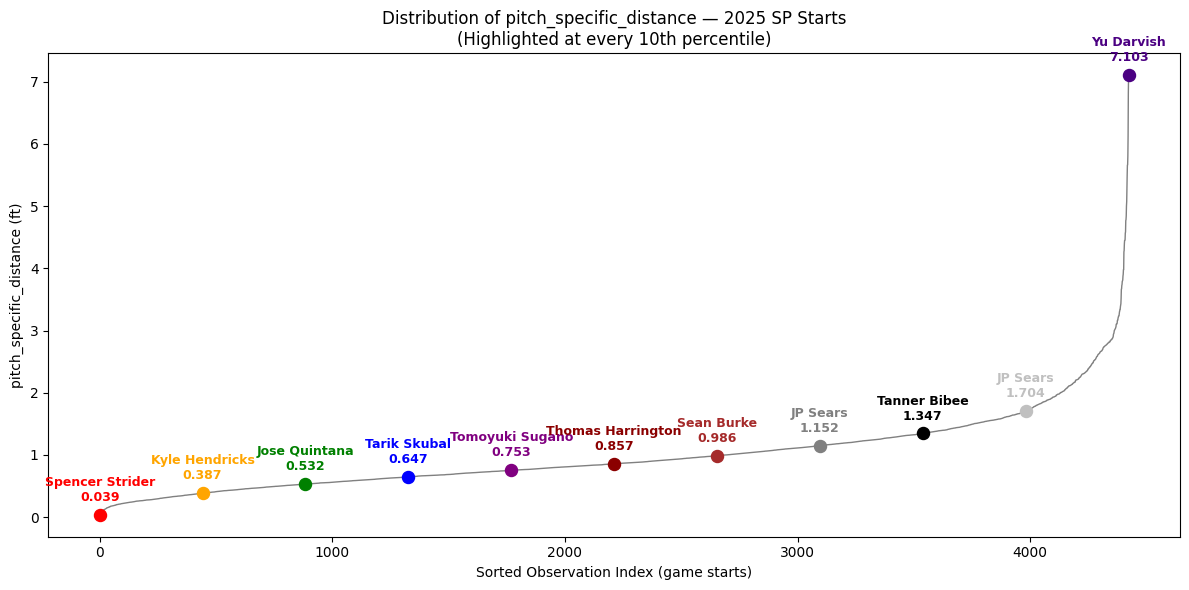

In [38]:
sorted_df = (
    pitch_with_largest_distance
    .dropna(subset=['pitch_specific_distance'])
    .sort_values('pitch_specific_distance')
    .reset_index(drop=True)
)

n = len(sorted_df)
percentile_fractions = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
highlight_indices = [min(max(int(p * (n - 1)), 0), n - 1) for p in percentile_fractions]
highlight_colors  = ['red', 'orange', 'green', 'blue', 'purple',
                     'darkred', 'brown', 'gray', 'black', 'silver', 'indigo']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(sorted_df['pitch_specific_distance'].values,
        label='All starts', color='gray', linewidth=1)

for idx, color in zip(highlight_indices, highlight_colors):
    row  = sorted_df.iloc[idx]
    dist = row['pitch_specific_distance']
    name = row.get('Name') if pd.notna(row.get('Name')) else str(row['pitcher_id'])

    ax.scatter(idx, dist, s=75, color=color, zorder=5)
    ax.annotate(f"{name}\n{dist:.3f}", (idx, dist),
                textcoords="offset points", xytext=(0, 10),
                ha='center', color=color, fontsize=9, fontweight='bold')

ax.set_xlabel('Sorted Observation Index (game starts)')
ax.set_ylabel('pitch_specific_distance (ft)')
ax.set_title('Distribution of pitch_specific_distance — 2025 SP Starts\n'
             '(Highlighted at every 10th percentile)')
plt.tight_layout()
plt.show()

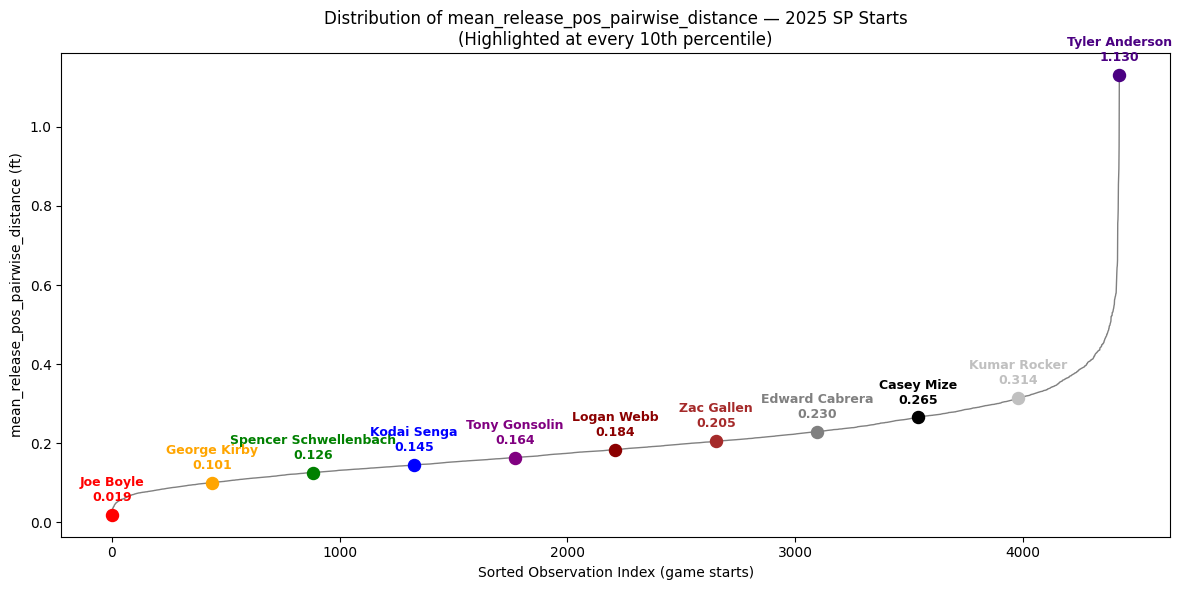

In [39]:
sorted_df = (
    pitch_with_largest_distance
    .dropna(subset=['mean_release_pos_pairwise_distance'])
    .sort_values('mean_release_pos_pairwise_distance')
    .reset_index(drop=True)
)

n = len(sorted_df)
percentile_fractions = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
highlight_indices = [min(max(int(p * (n - 1)), 0), n - 1) for p in percentile_fractions]
highlight_colors  = ['red', 'orange', 'green', 'blue', 'purple',
                     'darkred', 'brown', 'gray', 'black', 'silver', 'indigo']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(sorted_df['mean_release_pos_pairwise_distance'].values,
        label='All starts', color='gray', linewidth=1)

for idx, color in zip(highlight_indices, highlight_colors):
    row  = sorted_df.iloc[idx]
    dist = row['mean_release_pos_pairwise_distance']
    name = row.get('Name') if pd.notna(row.get('Name')) else str(row['pitcher_id'])

    ax.scatter(idx, dist, s=75, color=color, zorder=5)
    ax.annotate(f"{name}\n{dist:.3f}", (idx, dist),
                textcoords="offset points", xytext=(0, 10),
                ha='center', color=color, fontsize=9, fontweight='bold')

ax.set_xlabel('Sorted Observation Index (game starts)')
ax.set_ylabel('mean_release_pos_pairwise_distance (ft)')
ax.set_title('Distribution of mean_release_pos_pairwise_distance — 2025 SP Starts\n'
             '(Highlighted at every 10th percentile)')
plt.tight_layout()
plt.show()

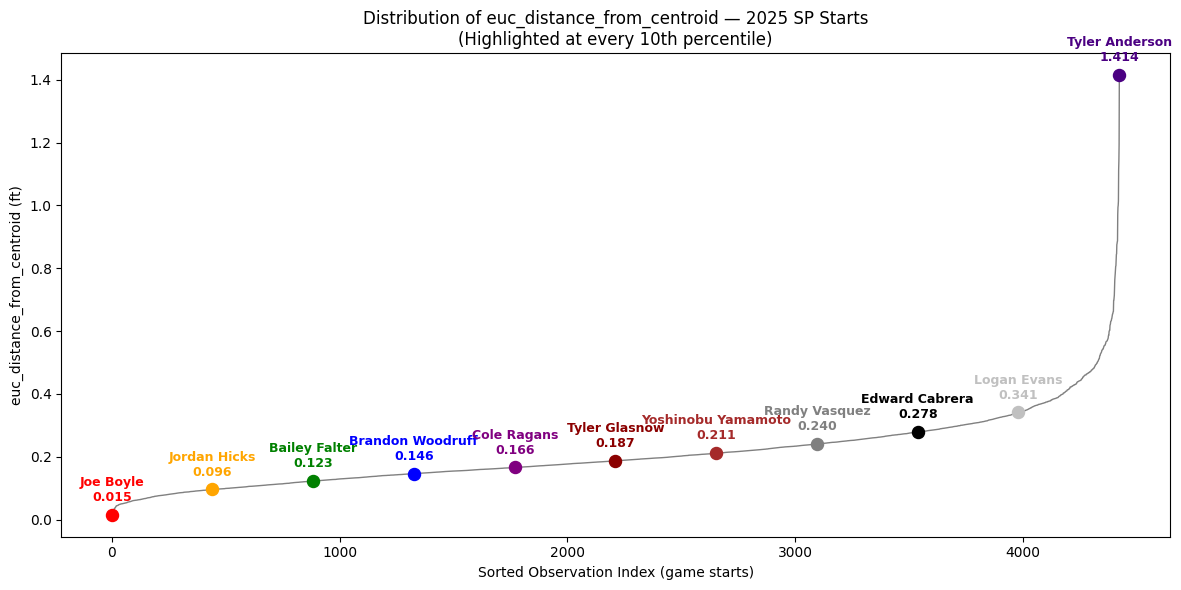

In [40]:
sorted_df = (
    pitch_with_largest_distance_centroid
    .dropna(subset=['euc_distance_from_centroid'])
    .sort_values('euc_distance_from_centroid')
    .reset_index(drop=True)
)

n = len(sorted_df)
percentile_fractions = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
highlight_indices = [min(max(int(p * (n - 1)), 0), n - 1) for p in percentile_fractions]
highlight_colors  = ['red', 'orange', 'green', 'blue', 'purple',
                     'darkred', 'brown', 'gray', 'black', 'silver', 'indigo']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(sorted_df['euc_distance_from_centroid'].values,
        label='All starts', color='gray', linewidth=1)

for idx, color in zip(highlight_indices, highlight_colors):
    row  = sorted_df.iloc[idx]
    dist = row['euc_distance_from_centroid']
    name = row.get('Name') if pd.notna(row.get('Name')) else str(row['pitcher_id'])

    ax.scatter(idx, dist, s=75, color=color, zorder=5)
    ax.annotate(f"{name}\n{dist:.3f}", (idx, dist),
                textcoords="offset points", xytext=(0, 10),
                ha='center', color=color, fontsize=9, fontweight='bold')

ax.set_xlabel('Sorted Observation Index (game starts)')
ax.set_ylabel('euc_distance_from_centroid (ft)')
ax.set_title('Distribution of euc_distance_from_centroid — 2025 SP Starts\n'
             '(Highlighted at every 10th percentile)')
plt.tight_layout()
plt.show()

## 28. Type Coercion and Outlier Capping

Convert key rate-stat columns from string to float (the MLB API returns them as strings).
Cap `era` at 600 for appearances where a pitcher recorded 0 outs (prevents divide-by-zero
infinity values from distorting correlations and plots).

In [41]:
def to_float2(val) -> float:
    """Safely convert a value to float, rounded to 2 decimal places. Returns NaN on failure."""
    try:
        return round(float(val), 2)
    except Exception:
        return np.nan


for col in ['whip', 'era', 'avg', 'ops', 'slg']:
    if col in pitch_with_largest_distance.columns:
        pitch_with_largest_distance[col] = pitch_with_largest_distance[col].apply(to_float2)

# Replace infinite ERA values (0 IP outs) with a sentinel cap of 600
pitch_with_largest_distance.loc[np.isinf(pitch_with_largest_distance['era']), 'era'] = 600.0

print("Type coercion complete.")
pitch_with_largest_distance[['era', 'whip', 'avg', 'ops', 'slg']].describe()

Type coercion complete.


,era,whip,avg,ops,slg
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,5.980068,1.276196,0.243083,0.733506,0.418759
std,17.981114,0.345928,0.047735,0.320050,0.226887
min,0.000000,0.140000,0.000000,0.000000,0.000000
25%,1.500000,1.100000,0.220000,0.510000,0.260000
50%,3.600000,1.260000,0.240000,0.700000,0.390000
75%,7.060000,1.400000,0.270000,0.910000,0.540000
max,630.000000,12.000000,0.880000,2.620000,2.000000


In [42]:
def to_float2(val) -> float:
    """Safely convert a value to float, rounded to 2 decimal places. Returns NaN on failure."""
    try:
        return round(float(val), 2)
    except Exception:
        return np.nan


for col in ['whip', 'era', 'avg', 'ops', 'slg']:
    if col in pitch_with_largest_distance_centroid.columns:
        pitch_with_largest_distance_centroid[col] = pitch_with_largest_distance_centroid[col].apply(to_float2)

# Replace infinite ERA values (0 IP outs) with a sentinel cap of 600
pitch_with_largest_distance_centroid.loc[np.isinf(pitch_with_largest_distance_centroid['era']), 'era'] = 600.0

print("Type coercion complete.")
pitch_with_largest_distance_centroid[['era', 'whip', 'avg', 'ops', 'slg']].describe()

Type coercion complete.


,era,whip,avg,ops,slg
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,5.980068,1.276196,0.243083,0.733506,0.418759
std,17.981114,0.345928,0.047735,0.320050,0.226887
min,0.000000,0.140000,0.000000,0.000000,0.000000
25%,1.500000,1.100000,0.220000,0.510000,0.260000
50%,3.600000,1.260000,0.240000,0.700000,0.390000
75%,7.060000,1.400000,0.270000,0.910000,0.540000
max,630.000000,12.000000,0.880000,2.620000,2.000000


## 29. Scatter Plot: ERA vs. Tunneling Distance (Raw)

Each point is one game start. The red line is the OLS best-fit. Pearson r is annotated
to quantify the linear relationship between a pitcher's release-point consistency and their ERA.

A **negative** correlation would indicate that better tunneling (smaller distance) correlates
with lower ERA; a **positive** value would suggest the opposite.

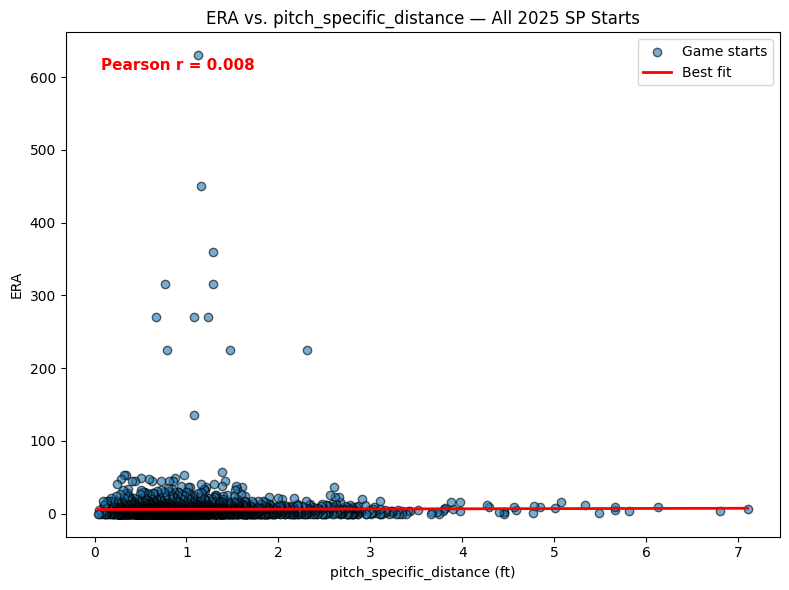

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))

valid = pitch_with_largest_distance[
    pitch_with_largest_distance['pitch_specific_distance'].notna() &
    pitch_with_largest_distance['era'].notna()
]

ax.scatter(valid['pitch_specific_distance'], valid['era'],
           alpha=0.6, edgecolor='k', label='Game starts')

if len(valid) >= 2:
    x = valid['pitch_specific_distance']
    y = valid['era']
    fit = np.polyfit(x, y, 1)
    ax.plot(x, np.polyval(fit, x), color='red', linewidth=2, label='Best fit')

    r = np.corrcoef(x, y)[0, 1]
    ax.annotate(f"Pearson r = {r:.3f}", xy=(0.05, 0.95), xycoords='axes fraction',
                ha='left', va='top', fontsize=11, color='red', fontweight='bold')

ax.set_xlabel('pitch_specific_distance (ft)')
ax.set_ylabel('ERA')
ax.set_title('ERA vs. pitch_specific_distance — All 2025 SP Starts')
ax.legend()
plt.tight_layout()
plt.show()

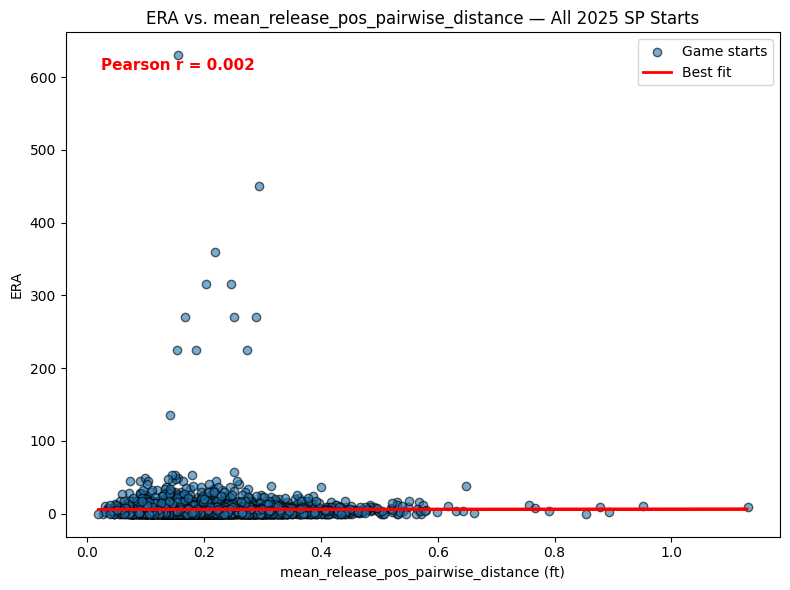

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))

valid = pitch_with_largest_distance[
    pitch_with_largest_distance['mean_release_pos_pairwise_distance'].notna() &
    pitch_with_largest_distance['era'].notna()
]

ax.scatter(valid['mean_release_pos_pairwise_distance'], valid['era'],
           alpha=0.6, edgecolor='k', label='Game starts')

if len(valid) >= 2:
    x = valid['mean_release_pos_pairwise_distance']
    y = valid['era']
    fit = np.polyfit(x, y, 1)
    ax.plot(x, np.polyval(fit, x), color='red', linewidth=2, label='Best fit')

    r = np.corrcoef(x, y)[0, 1]
    ax.annotate(f"Pearson r = {r:.3f}", xy=(0.05, 0.95), xycoords='axes fraction',
                ha='left', va='top', fontsize=11, color='red', fontweight='bold')

ax.set_xlabel('mean_release_pos_pairwise_distance (ft)')
ax.set_ylabel('ERA')
ax.set_title('ERA vs. mean_release_pos_pairwise_distance — All 2025 SP Starts')
ax.legend()
plt.tight_layout()
plt.show()

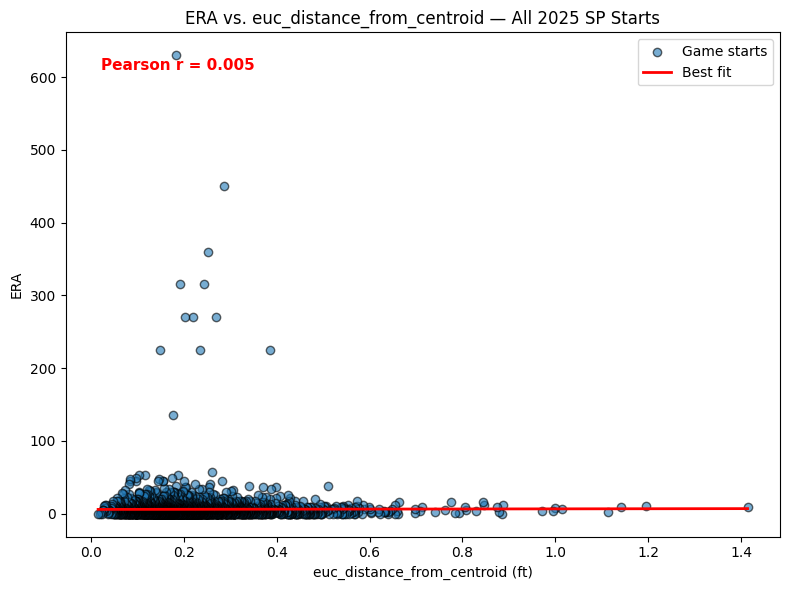

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))

valid = pitch_with_largest_distance_centroid[
    pitch_with_largest_distance_centroid['euc_distance_from_centroid'].notna() &
    pitch_with_largest_distance_centroid['era'].notna()
]

ax.scatter(valid['euc_distance_from_centroid'], valid['era'],
           alpha=0.6, edgecolor='k', label='Game starts')

if len(valid) >= 2:
    x = valid['euc_distance_from_centroid']
    y = valid['era']
    fit = np.polyfit(x, y, 1)
    ax.plot(x, np.polyval(fit, x), color='red', linewidth=2, label='Best fit')

    r = np.corrcoef(x, y)[0, 1]
    ax.annotate(f"Pearson r = {r:.3f}", xy=(0.05, 0.95), xycoords='axes fraction',
                ha='left', va='top', fontsize=11, color='red', fontweight='bold')

ax.set_xlabel('euc_distance_from_centroid (ft)')
ax.set_ylabel('ERA')
ax.set_title('ERA vs. euc_distance_from_centroid — All 2025 SP Starts')
ax.legend()
plt.tight_layout()
plt.show()

## 30. Scatter Plot: ERA vs. Tunneling Distance (ERA Capped at 27)

Extreme ERA values (from very short outings) can distort the visual and the correlation
coefficient. This plot caps ERA at 27 to improve readability while re-computing Pearson r
on the capped dataset.

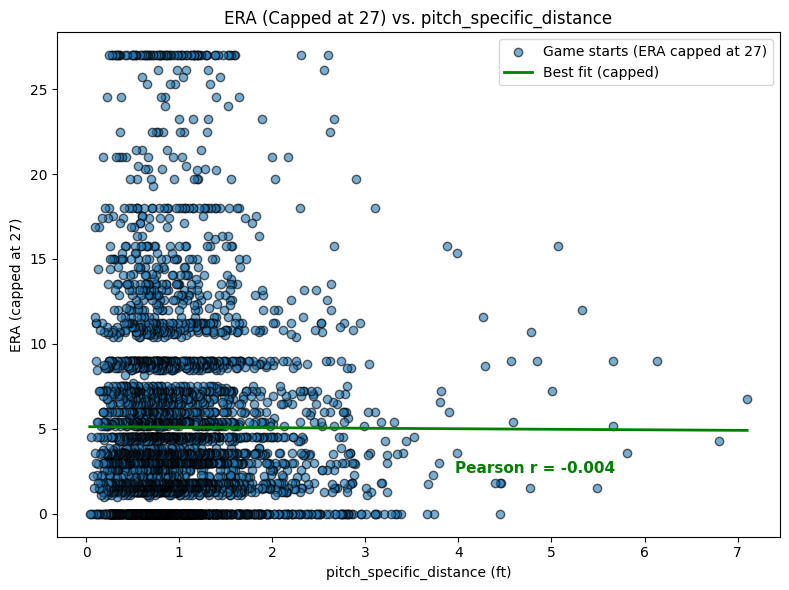

In [46]:
clipped_df = pitch_with_largest_distance.copy()
clipped_df.loc[clipped_df['era'] > 27, 'era'] = 27

valid_clipped = clipped_df[
    clipped_df['pitch_specific_distance'].notna() &
    clipped_df['era'].notna()
]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(valid_clipped['pitch_specific_distance'], valid_clipped['era'],
           alpha=0.6, edgecolor='k', label='Game starts (ERA capped at 27)')

if len(valid_clipped) >= 2:
    x = valid_clipped['pitch_specific_distance']
    y = valid_clipped['era']
    fit = np.polyfit(x, y, 1)
    ax.plot(x, np.polyval(fit, x), color='green', linewidth=2, label='Best fit (capped)')

    r = np.corrcoef(x, y)[0, 1]
    ax.annotate(f"Pearson r = {r:.3f}", xy=(0.55, 0.15), xycoords='axes fraction',
                ha='left', va='top', fontsize=11, color='green', fontweight='bold')

ax.set_xlabel('pitch_specific_distance (ft)')
ax.set_ylabel('ERA (capped at 27)')
ax.set_title('ERA (Capped at 27) vs. pitch_specific_distance')
ax.legend()
plt.tight_layout()
plt.show()

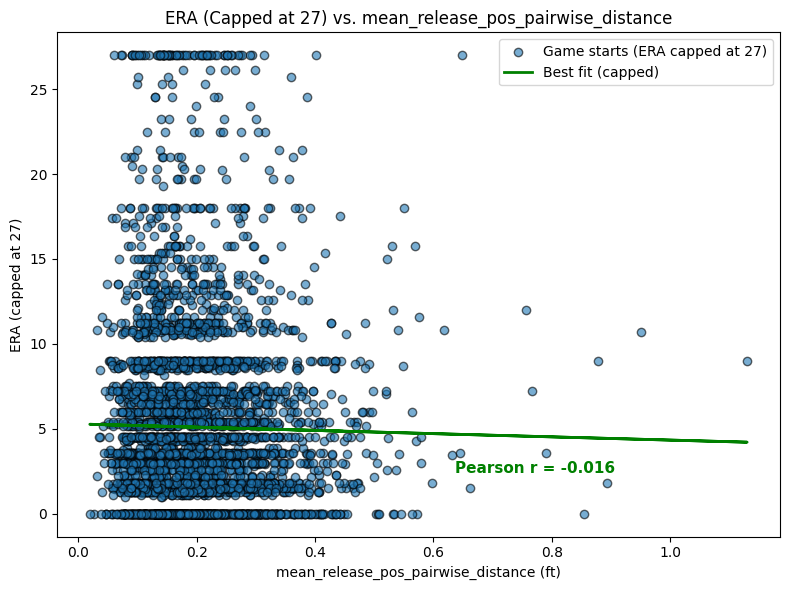

In [47]:
clipped_df = pitch_with_largest_distance.copy()
clipped_df.loc[clipped_df['era'] > 27, 'era'] = 27

valid_clipped = clipped_df[
    clipped_df['mean_release_pos_pairwise_distance'].notna() &
    clipped_df['era'].notna()
]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(valid_clipped['mean_release_pos_pairwise_distance'], valid_clipped['era'],
           alpha=0.6, edgecolor='k', label='Game starts (ERA capped at 27)')

if len(valid_clipped) >= 2:
    x = valid_clipped['mean_release_pos_pairwise_distance']
    y = valid_clipped['era']
    fit = np.polyfit(x, y, 1)
    ax.plot(x, np.polyval(fit, x), color='green', linewidth=2, label='Best fit (capped)')

    r = np.corrcoef(x, y)[0, 1]
    ax.annotate(f"Pearson r = {r:.3f}", xy=(0.55, 0.15), xycoords='axes fraction',
                ha='left', va='top', fontsize=11, color='green', fontweight='bold')

ax.set_xlabel('mean_release_pos_pairwise_distance (ft)')
ax.set_ylabel('ERA (capped at 27)')
ax.set_title('ERA (Capped at 27) vs. mean_release_pos_pairwise_distance')
ax.legend()
plt.tight_layout()
plt.show()

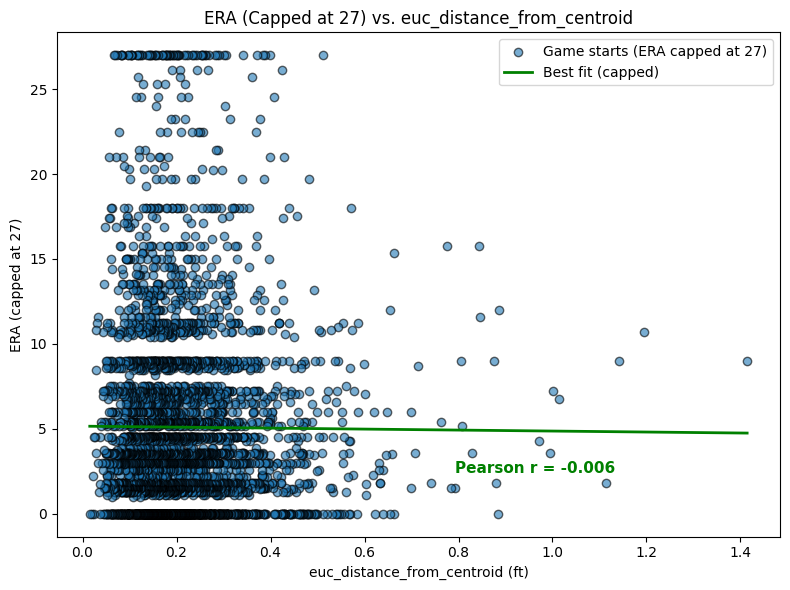

In [48]:
clipped_df = pitch_with_largest_distance_centroid.copy()
clipped_df.loc[clipped_df['era'] > 27, 'era'] = 27

valid_clipped = clipped_df[
    clipped_df['euc_distance_from_centroid'].notna() &
    clipped_df['era'].notna()
]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(valid_clipped['euc_distance_from_centroid'], valid_clipped['era'],
           alpha=0.6, edgecolor='k', label='Game starts (ERA capped at 27)')

if len(valid_clipped) >= 2:
    x = valid_clipped['euc_distance_from_centroid']
    y = valid_clipped['era']
    fit = np.polyfit(x, y, 1)
    ax.plot(x, np.polyval(fit, x), color='green', linewidth=2, label='Best fit (capped)')

    r = np.corrcoef(x, y)[0, 1]
    ax.annotate(f"Pearson r = {r:.3f}", xy=(0.55, 0.15), xycoords='axes fraction',
                ha='left', va='top', fontsize=11, color='green', fontweight='bold')

ax.set_xlabel('euc_distance_from_centroid (ft)')
ax.set_ylabel('ERA (capped at 27)')
ax.set_title('ERA (Capped at 27) vs. euc_distance_from_centroid')
ax.legend()
plt.tight_layout()
plt.show()

## 31. Pearson Correlation — ERA vs. Tunneling Distance

Compute and print the Pearson r and p-value for the full (uncapped) dataset.

In [49]:
valid = pitch_with_largest_distance[
    pitch_with_largest_distance['pitch_specific_distance'].notna() &
    pitch_with_largest_distance['era'].notna()
]

if len(valid) >= 2:
    r, p = pearsonr(
        valid['pitch_specific_distance'],
        valid['era']
    )
    print(f"Pearson r  : {r:.4f}")
    print(f"p-value    : {p:.4g}")
    print(f"n (starts) : {len(valid)}")
else:
    print("Insufficient data to compute Pearson r.")

Pearson r  : 0.0084
p-value    : 0.5757
n (starts) : 4424


In [50]:
valid = pitch_with_largest_distance[
    pitch_with_largest_distance['mean_release_pos_pairwise_distance'].notna() &
    pitch_with_largest_distance['era'].notna()
]

if len(valid) >= 2:
    r, p = pearsonr(
        valid['mean_release_pos_pairwise_distance'],
        valid['era']
    )
    print(f"Pearson r  : {r:.4f}")
    print(f"p-value    : {p:.4g}")
    print(f"n (starts) : {len(valid)}")
else:
    print("Insufficient data to compute Pearson r.")

Pearson r  : 0.0018
p-value    : 0.9073
n (starts) : 4424


In [51]:
valid = pitch_with_largest_distance_centroid[
    pitch_with_largest_distance_centroid['euc_distance_from_centroid'].notna() &
    pitch_with_largest_distance_centroid['era'].notna()
]

if len(valid) >= 2:
    r, p = pearsonr(
        valid['euc_distance_from_centroid'],
        valid['era']
    )
    print(f"Pearson r  : {r:.4f}")
    print(f"p-value    : {p:.4g}")
    print(f"n (starts) : {len(valid)}")
else:
    print("Insufficient data to compute Pearson r.")

Pearson r  : 0.0050
p-value    : 0.7401
n (starts) : 4424


## 32. Season-Long Tunnel Averages per Pitcher

Collapse the per-start table to one row per pitcher by averaging all numeric
release-position, arm-angle, and release-speed metrics across all of their 2025 starts.
The result (`Season_Long_Tunnel`) is the season-level profile used for ranking.

## THIS UTILIZES PREFIXES

In [52]:
# Aggregate: mean over all starts, ignoring NaN
Season_Long_Tunnel_Averages = (
    pitch_with_largest_distance
    .groupby('pitcher_id')["mean_release_pos_pairwise_distance"]
    .mean()
    .reset_index()
)

Season_Long_Tunnel_Averages = Season_Long_Tunnel_Averages.sort_values(
    by='mean_release_pos_pairwise_distance', ascending=False
).reset_index(drop=True)

# Assuming MLB_IDs_2025 is a DataFrame that contains columns 'pitcher_id' and 'Name'
Season_Long_Tunnel_Averages = Season_Long_Tunnel_Averages.merge(
    MLB_IDs_2025[['MLBAMID', 'Name']],
    left_on='pitcher_id', right_on='MLBAMID',
    how='left'
).drop(columns=['MLBAMID'])

print(f"Season_Long_Tunnel_Averages shape: {Season_Long_Tunnel_Averages.shape}")
Season_Long_Tunnel_Averages.head(20)

Season_Long_Tunnel_Averages shape: (252, 3)


,pitcher_id,mean_release_pos_pairwise_distance,Name
0,542881,0.514724,Tyler Anderson
1,571510,0.448663,Matthew Boyd
2,571760,0.447382,Andrew Heaney
3,680730,0.446607,Mitchell Parker
4,657376,0.441310,Clarke Schmidt
5,661563,0.409844,Luis Gil
6,641482,0.407213,Nestor Cortes
7,625643,0.406747,Reynaldo Lopez
8,506433,0.380895,Yu Darvish
9,608331,0.379903,Max Fried


In [53]:
# Aggregate: mean over all starts, ignoring NaN
temp_df = (
    pitch_with_largest_distance_centroid
    .groupby('pitcher_id')["euc_distance_from_centroid"]
    .mean()
    .reset_index()
)

# Merge the euc_distance_from_centroid column from temp_df with Season_Long_Tunnel_Averages based on pitcher_id
Season_Long_Tunnel_Averages = Season_Long_Tunnel_Averages.merge(
    temp_df[['pitcher_id', 'euc_distance_from_centroid']],
    on='pitcher_id',
    how='left'
)


print(f"Season_Long_Tunnel_Averages shape: {Season_Long_Tunnel_Averages.shape}")
Season_Long_Tunnel_Averages.head(20)

Season_Long_Tunnel_Averages shape: (252, 4)


,pitcher_id,mean_release_pos_pairwise_distance,Name,euc_distance_from_centroid
0,542881,0.514724,Tyler Anderson,0.560770
1,571510,0.448663,Matthew Boyd,0.531181
2,571760,0.447382,Andrew Heaney,0.582879
3,680730,0.446607,Mitchell Parker,0.412969
4,657376,0.441310,Clarke Schmidt,0.428578
5,661563,0.409844,Luis Gil,0.362625
6,641482,0.407213,Nestor Cortes,0.406353
7,625643,0.406747,Reynaldo Lopez,0.331204
8,506433,0.380895,Yu Darvish,0.683556
9,608331,0.379903,Max Fried,0.431230


## 33. Correlation Table — Tunneling Distance vs. Outcome Metrics (Per Start)

Compute Pearson r between `mean_release_pos_pairwise_distance` and a set of
per-start performance variables to identify which outcomes most closely track
release-point consistency.

In [54]:
outcome_vars = [
    'era', 'whip', 'strikeoutsPer9Inn', 'homeRunsper9', 'game_score',
    'strikePercentage', 'strikeoutWalkRatio', 'pitchesPerInning',
    'avg', 'obp', 'slg', 'ops',
    'numberOfPitches', 'inningsPitches', 'earnedRuns', 'wins', 'losses',
]

# Ensure key column is numeric
pitch_with_largest_distance['pitch_specific_distance'] = pd.to_numeric(
    pitch_with_largest_distance['pitch_specific_distance'], errors='coerce'
)

pitch_specific_distance_correlation = {}
for var in outcome_vars:
    if var in pitch_with_largest_distance.columns:
        pitch_with_largest_distance[var] = pd.to_numeric(pitch_with_largest_distance[var], errors='coerce')
        r = pitch_with_largest_distance['pitch_specific_distance'].corr(pitch_with_largest_distance[var])
        pitch_specific_distance_correlation[var] = r

print("Pearson r with pitch_specific_distance:")
for k, v in sorted(pitch_specific_distance_correlation.items(), key=lambda x: abs(x[1] or 0), reverse=True):
    print(f"  {k:<30} {v:.4f}" if v is not None else f"  {k:<30} N/A")

Pearson r with pitch_specific_distance:
  strikeoutsPer9Inn              -0.0810
  numberOfPitches                -0.0447
  strikeoutWalkRatio             -0.0353
  game_score                     -0.0239
  avg                            0.0235
  wins                           -0.0181
  whip                           -0.0108
  slg                            0.0087
  earnedRuns                     -0.0085
  era                            0.0084
  obp                            -0.0048
  ops                            0.0043
  losses                         -0.0018
  strikePercentage               -0.0011
  pitchesPerInning               0.0009


In [55]:
outcome_vars = [
    'era', 'whip', 'strikeoutsPer9Inn', 'homeRunsper9', 'game_score',
    'strikePercentage', 'strikeoutWalkRatio', 'pitchesPerInning',
    'avg', 'obp', 'slg', 'ops',
    'numberOfPitches', 'inningsPitches', 'earnedRuns', 'wins', 'losses',
]

# Ensure key column is numeric
pitch_with_largest_distance['mean_release_pos_pairwise_distance'] = pd.to_numeric(
    pitch_with_largest_distance['mean_release_pos_pairwise_distance'], errors='coerce'
)

mean_release_pos_pairwise_distance_correlation = {}
for var in outcome_vars:
    if var in pitch_with_largest_distance.columns:
        pitch_with_largest_distance[var] = pd.to_numeric(pitch_with_largest_distance[var], errors='coerce')
        r = pitch_with_largest_distance['mean_release_pos_pairwise_distance'].corr(pitch_with_largest_distance[var])
        mean_release_pos_pairwise_distance_correlation[var] = r

print("Pearson r with mean_release_pos_pairwise_distance:")
for k, v in sorted(mean_release_pos_pairwise_distance_correlation.items(), key=lambda x: abs(x[1] or 0), reverse=True):
    print(f"  {k:<30} {v:.4f}" if v is not None else f"  {k:<30} N/A")

Pearson r with mean_release_pos_pairwise_distance:
  strikeoutsPer9Inn              -0.0323
  numberOfPitches                -0.0297
  earnedRuns                     -0.0251
  strikeoutWalkRatio             -0.0215
  obp                            -0.0175
  whip                           0.0163
  pitchesPerInning               0.0126
  ops                            -0.0125
  wins                           -0.0107
  losses                         -0.0092
  slg                            -0.0088
  strikePercentage               0.0055
  game_score                     -0.0042
  era                            0.0018
  avg                            -0.0008


In [56]:
outcome_vars = [
    'era', 'whip', 'strikeoutsPer9Inn', 'homeRunsper9', 'game_score',
    'strikePercentage', 'strikeoutWalkRatio', 'pitchesPerInning',
    'avg', 'obp', 'slg', 'ops',
    'numberOfPitches', 'inningsPitches', 'earnedRuns', 'wins', 'losses',
]

# Ensure key column is numeric
pitch_with_largest_distance_centroid['euc_distance_from_centroid'] = pd.to_numeric(
    pitch_with_largest_distance_centroid['euc_distance_from_centroid'], errors='coerce'
)

euc_distance_from_centroid_correlation = {}
for var in outcome_vars:
    if var in pitch_with_largest_distance_centroid.columns:
        pitch_with_largest_distance_centroid[var] = pd.to_numeric(pitch_with_largest_distance_centroid[var], errors='coerce')
        r = pitch_with_largest_distance_centroid['euc_distance_from_centroid'].corr(pitch_with_largest_distance_centroid[var])
        euc_distance_from_centroid_correlation[var] = r

print("Pearson r with euc_distance_from_centroid:")
for k, v in sorted(euc_distance_from_centroid_correlation.items(), key=lambda x: abs(x[1] or 0), reverse=True):
    print(f"  {k:<30} {v:.4f}" if v is not None else f"  {k:<30} N/A")

Pearson r with euc_distance_from_centroid:
  strikeoutsPer9Inn              -0.0649
  numberOfPitches                -0.0405
  strikeoutWalkRatio             -0.0383
  wins                           -0.0215
  game_score                     -0.0209
  avg                            0.0160
  earnedRuns                     -0.0131
  whip                           0.0093
  obp                            -0.0089
  pitchesPerInning               0.0084
  era                            0.0050
  strikePercentage               -0.0047
  losses                         -0.0027
  ops                            -0.0021
  slg                            0.0017


In [57]:
# Combine all correlation dictionaries into a single DataFrame for easy viewing

# Make sure all dictionaries are present
# If 'pitch_specific_distance_correlation' not yet defined like the others, try to create/populate it if available
# (From context, assuming it's structured like the other correlation dicts)
try:
    pitch_specific_distance_correlation
except NameError:
    pitch_specific_distance_correlation = {}

# Collect all unique variable names across the dictionaries
all_vars = set(mean_release_pos_pairwise_distance_correlation) | set(euc_distance_from_centroid_correlation) | set(pitch_specific_distance_correlation)

# Build DataFrame
combined_corr_df = pd.DataFrame({
    'pitch_specific_distance':   [pitch_specific_distance_correlation.get(var, None) for var in all_vars],
    'mean_release_pos_pairwise_distance': [mean_release_pos_pairwise_distance_correlation.get(var, None) for var in all_vars],
    'euc_distance_from_centroid': [euc_distance_from_centroid_correlation.get(var, None) for var in all_vars],
}, index=list(all_vars))

# Optionally, sort by absolute value of (for example) 'pitch_specific_distance'
combined_corr_df = combined_corr_df.astype(float)
combined_corr_df = combined_corr_df.reindex(sorted(combined_corr_df.index), axis=0)

print("Combined correlation table:")
print(combined_corr_df.round(4).to_string())

Combined correlation table:
                    pitch_specific_distance  mean_release_pos_pairwise_distance  euc_distance_from_centroid
avg                                  0.0235                             -0.0008                      0.0160
earnedRuns                          -0.0085                             -0.0251                     -0.0131
era                                  0.0084                              0.0018                      0.0050
game_score                          -0.0239                             -0.0042                     -0.0209
losses                              -0.0018                             -0.0092                     -0.0027
numberOfPitches                     -0.0447                             -0.0297                     -0.0405
obp                                 -0.0048                             -0.0175                     -0.0089
ops                                  0.0043                             -0.0125                     -0.0021


# This table above shows that there's not much of a significance between release location & key metrics of season success for starting pitchers. The most significant value is K/9, which implies that in general, less than 1% of the variance is explained by pitch_specific_distance (r^2 = -0.0810). 

# This also implies that pitch_specific_distance has the most significance, as opposed to the average distance values. This makes sense that pitchers may have one pitch that significantly differs in release location vs. general variance. 

In [69]:
# Select numeric columns only (excluding 'pitch_specific_distance' itself)
outcome_vars = [
    'era', 'whip', 'strikeoutsPer9Inn', 'game_score',
    'strikePercentage', 'strikeoutWalkRatio', 'pitchesPerInning',
    'avg', 'obp', 'slg', 'ops',
    'numberOfPitches', 'inningsPitched', 'earnedRuns', 'wins', 'losses',
]

target_col = 'pitch_specific_distance'
other_numeric_cols = [col for col in outcome_vars if col != target_col]

# Store results
pval_results = []

for col in other_numeric_cols:
    valid = pitch_with_largest_distance[[target_col, col]].dropna()
    if len(valid) >= 2:
        _, pval = pearsonr(valid[target_col], valid[col])
        pval_results.append({'column': col, 'p_value': pval, 'n': len(valid)})
    else:
        pval_results.append({'column': col, 'p_value': None, 'n': len(valid)})

pvals_pitch_specific_distance = pd.DataFrame(pval_results)
print("P-values for correlations with 'pitch_specific_distance':")
print(pvals_pitch_specific_distance)

P-values for correlations with 'pitch_specific_distance':
                column       p_value     n
0                  era  5.756588e-01  4424
1                 whip  4.735908e-01  4424
2    strikeoutsPer9Inn  6.850449e-08  4424
3           game_score  1.117158e-01  4424
4     strikePercentage  9.396155e-01  4424
5   strikeoutWalkRatio  3.352251e-02  3632
6     pitchesPerInning  9.538205e-01  4424
7                  avg  1.177654e-01  4424
8                  obp  7.470919e-01  4424
9                  slg  5.623321e-01  4424
10                 ops  7.730989e-01  4424
11     numberOfPitches  2.960726e-03  4424
12      inningsPitched  4.643687e-02  4424
13          earnedRuns  5.726062e-01  4424
14                wins  2.277063e-01  4424
15              losses  9.053502e-01  4424


In [70]:
# Select numeric columns only (excluding 'mean_release_pos_pairwise_distance' itself)
outcome_vars = [
    'era', 'whip', 'strikeoutsPer9Inn', 'game_score',
    'strikePercentage', 'strikeoutWalkRatio', 'pitchesPerInning',
    'avg', 'obp', 'slg', 'ops',
    'numberOfPitches', 'inningsPitched', 'earnedRuns', 'wins', 'losses',
]

target_col = 'mean_release_pos_pairwise_distance'
other_numeric_cols = [col for col in outcome_vars if col != target_col]

# Store results
pval_results = []

for col in other_numeric_cols:
    valid = pitch_with_largest_distance[[target_col, col]].dropna()
    if len(valid) >= 2:
        _, pval = pearsonr(valid[target_col], valid[col])
        pval_results.append({'column': col, 'p_value': pval, 'n': len(valid)})
    else:
        pval_results.append({'column': col, 'p_value': None, 'n': len(valid)})

pvals_mean_release_pos_pairwise_distance = pd.DataFrame(pval_results)
print("P-values for correlations with 'mean_release_pos_pairwise_distance':")
print(pvals_mean_release_pos_pairwise_distance)

P-values for correlations with 'mean_release_pos_pairwise_distance':
                column   p_value     n
0                  era  0.907328  4424
1                 whip  0.277758  4424
2    strikeoutsPer9Inn  0.031691  4424
3           game_score  0.780107  4424
4     strikePercentage  0.715284  4424
5   strikeoutWalkRatio  0.195823  3632
6     pitchesPerInning  0.402966  4424
7                  avg  0.955844  4424
8                  obp  0.245515  4424
9                  slg  0.556855  4424
10                 ops  0.404857  4424
11     numberOfPitches  0.047999  4424
12      inningsPitched  0.036963  4424
13          earnedRuns  0.094429  4424
14                wins  0.476883  4424
15              losses  0.540797  4424


In [71]:
# Select numeric columns only (excluding 'euc_distance_from_centroid' itself)
outcome_vars = [
    'era', 'whip', 'strikeoutsPer9Inn', 'game_score',
    'strikePercentage', 'strikeoutWalkRatio', 'pitchesPerInning',
    'avg', 'obp', 'slg', 'ops',
    'numberOfPitches', 'inningsPitched', 'earnedRuns', 'wins', 'losses',
]

target_col = 'euc_distance_from_centroid'
other_numeric_cols = [col for col in outcome_vars if col != target_col]

# Store results
pval_results = []

for col in other_numeric_cols:
    valid = pitch_with_largest_distance_centroid[[target_col, col]].dropna()
    if len(valid) >= 2:
        _, pval = pearsonr(valid[target_col], valid[col])
        pval_results.append({'column': col, 'p_value': pval, 'n': len(valid)})
    else:
        pval_results.append({'column': col, 'p_value': None, 'n': len(valid)})

pvals_euc_distance_from_centroid = pd.DataFrame(pval_results)
print("P-values for correlations with 'euc_distance_from_centroid':")
print(pvals_euc_distance_from_centroid)

P-values for correlations with 'euc_distance_from_centroid':
                column   p_value     n
0                  era  0.740125  4424
1                 whip  0.538209  4424
2    strikeoutsPer9Inn  0.000016  4424
3           game_score  0.164443  4424
4     strikePercentage  0.752689  4424
5   strikeoutWalkRatio  0.021139  3632
6     pitchesPerInning  0.576398  4424
7                  avg  0.286310  4424
8                  obp  0.553909  4424
9                  slg  0.912014  4424
10                 ops  0.889338  4424
11     numberOfPitches  0.007015  4424
12      inningsPitched  0.017580  4424
13          earnedRuns  0.384938  4424
14                wins  0.152936  4424
15              losses  0.856074  4424


In [72]:
# Create a new dataframe that contains the column name and associated p-values from each p-value dataframe

# Ensure the relevant dataframes exist: 
# pvals_pitch_specific_distance, pvals_mean_release_pos_pairwise_distance, pvals_euc_distance_from_centroid

# Rename 'p_value' columns for clear merging
df1 = pvals_pitch_specific_distance.rename(columns={'p_value': 'pitch_specific_distance'})
df2 = pvals_mean_release_pos_pairwise_distance.rename(columns={'p_value': 'mean_release_pos_pairwise_distance'})
df3 = pvals_euc_distance_from_centroid.rename(columns={'p_value': 'euc_distance_from_centroid'})

# Merge all three p-value results on the 'column' field
from functools import reduce

pval_dfs = [df1[['column', 'pitch_specific_distance']],
            df2[['column', 'mean_release_pos_pairwise_distance']],
            df3[['column', 'euc_distance_from_centroid']]]

pvals_merged = reduce(lambda left, right: pd.merge(left, right, on='column', how='outer'), pval_dfs)

print("Merged p-value DataFrame:")
print(pvals_merged)

Merged p-value DataFrame:
                column  pitch_specific_distance  \
0                  avg             1.177654e-01   
1           earnedRuns             5.726062e-01   
2                  era             5.756588e-01   
3           game_score             1.117158e-01   
4       inningsPitched             4.643687e-02   
5               losses             9.053502e-01   
6      numberOfPitches             2.960726e-03   
7                  obp             7.470919e-01   
8                  ops             7.730989e-01   
9     pitchesPerInning             9.538205e-01   
10                 slg             5.623321e-01   
11    strikePercentage             9.396155e-01   
12  strikeoutWalkRatio             3.352251e-02   
13   strikeoutsPer9Inn             6.850449e-08   
14                whip             4.735908e-01   
15                wins             2.277063e-01   

    mean_release_pos_pairwise_distance  euc_distance_from_centroid  
0                             0.95584

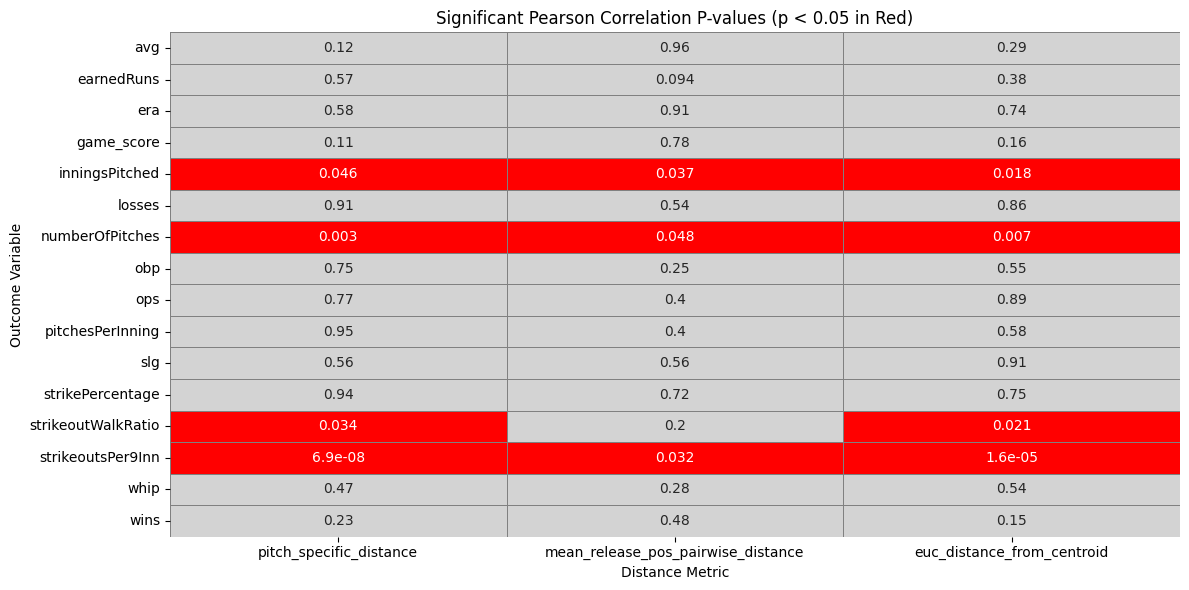

In [73]:
# Prepare a boolean mask indicating p-values below 0.05
mask = pvals_merged.set_index('column') < 0.05

# For the colormap: custom with only lightgray for non-significant, red for significant
from matplotlib.colors import ListedColormap

# Make a custom colormap: lightgray for >=0.05, red for <0.05
cmap = ListedColormap(['lightgray', 'red'])

# Get the data as a mask of significant (1 if <0.05 else 0)
plot_data = mask.astype(int)

plt.figure(figsize=(12, 6))
# Draw the heatmap
ax = sns.heatmap(
    plot_data,
    annot=pvals_merged.set_index('column').applymap(lambda x: f"{x:.2g}" if pd.notnull(x) else ""),
    fmt='',
    cmap=cmap,
    cbar=False,    # No colorbar since the scale is binary, not continuous
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Significant Pearson Correlation P-values (p < 0.05 in Red)")
plt.ylabel("Outcome Variable")
plt.xlabel("Distance Metric")
plt.tight_layout()
plt.show()

In [74]:
# List of columns to correlate (based on context you provided)
cols_to_correlate = [
    'era', 'whip', 'strikeoutsPer9Inn', 'homeRunsper9', 'game_score',
    'strikePercentage', 'strikeoutWalkRatio', 'pitchesPerInning',
    'avg', 'obp', 'slg', 'ops',
    'numberOfPitches', 'inningsPitches', 'earnedRuns', 'wins', 'losses'
]



results = []

for col in cols_to_correlate:
    if col in pitch_with_largest_distance.columns:
        valid = pitch_with_largest_distance[
            pitch_with_largest_distance['mean_release_pos_pairwise_distance'].notna() &
            pitch_with_largest_distance[col].notna()
        ]
        if len(valid) >= 2:
            r, p = pearsonr(
                valid['mean_release_pos_pairwise_distance'],
                valid[col]
            )
            results.append({
                'column': col,
                'pearson_r': r,
                'p_value': p,
                'n': len(valid)
            })
        else:
            results.append({
                'column': col,
                'pearson_r': None,
                'p_value': None,
                'n': len(valid)
            })


results_df = pd.DataFrame(results)
print(results_df)

                column  pearson_r   p_value     n
0                  era   0.001751  0.907328  4424
1                 whip   0.016322  0.277758  4424
2    strikeoutsPer9Inn  -0.032299  0.031691  4424
3           game_score  -0.004199  0.780107  4424
4     strikePercentage   0.005486  0.715284  4424
5   strikeoutWalkRatio  -0.021469  0.195823  3632
6     pitchesPerInning   0.012577  0.402966  4424
7                  avg  -0.000833  0.955844  4424
8                  obp  -0.017463  0.245515  4424
9                  slg  -0.008835  0.556855  4424
10                 ops  -0.012527  0.404857  4424
11     numberOfPitches  -0.029731  0.047999  4424
12          earnedRuns  -0.025148  0.094429  4424
13                wins  -0.010697  0.476883  4424
14              losses  -0.009198  0.540797  4424


## Across all three tunneling-distance metrics, correlations with traditional outcome stats (ERA, WHIP, AVG/OBP/SLG/OPS, wins/losses) were negligible (|r| < 0.02, r² < 0.04%) and not significant after correcting for the 48 comparisons run. The only relationship that survived Bonferroni correction (α ≈ 0.001) was strikeouts per 9 innings, which showed a small but statistically robust negative correlation with pitch_specific_distance (r = -0.081, p = 5.9×10⁻⁸, r² ≈ 0.65%) and with euc_distance_from_centroid (r = -0.065, p = 1.5×10⁻⁵, r² ≈ 0.42%) — i.e., pitchers with tighter release points on their most "out of tunnel" pitch trend toward modestly higher K/9. mean_release_pos_pairwise_distance showed the same direction but didn't clear the corrected threshold (p = 0.031, uncorrected only). Bottom line: release-point tunneling has a real but very small relationship with strikeout rate, and no detectable relationship with run-prevention or contact-quality outcomes at the per-start level.

## 37. Scatter Plot: Home Runs vs. Tunnel Percentile (Per Start)

Each point is one game start. Labels are placed at evenly spaced positions across
the x-axis to highlight representative pitchers at each tunneling level.

A positive trend would suggest that pitchers with worse tunneling (higher percentile)
allow more home runs — consistent with the hypothesis that batters who can read pitches
earlier make better contact.

In [ ]:
if 'homeRuns' not in .columns:
    raise KeyError("'homeRuns' column not found in merged_df.")

plot_df_hr = merged_df.dropna(subset=['Tunnel_Percentile', 'homeRuns', 'Name']).copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(plot_df_hr['Tunnel_Percentile'], plot_df_hr['homeRuns'],
           alpha=0.6, c='tab:blue', label='Game starts')

# OLS trend line
x = plot_df_hr['Tunnel_Percentile'].astype(float)
y = plot_df_hr['homeRuns'].astype(float)
fit = np.polyfit(x, y, 1)
ax.plot(x, np.poly1d(fit)(x), color='red', linestyle='--', linewidth=2, label='Trend line')

# Annotate 9 evenly spaced players across the x-axis range
annotation_indices = np.linspace(0, len(plot_df_hr) - 1, 9, dtype=int)
for idx in annotation_indices:
    row = plot_df_hr.iloc[idx]
    ax.annotate(
        str(row['Name']),
        (row['Tunnel_Percentile'], row['homeRuns']),
        textcoords='offset points', xytext=(5, 5),
        ha='left', fontsize=8, color='purple', alpha=0.8
    )

ax.set_xlabel('Tunnel Percentile (1 = best tunneling, 100 = worst)')
ax.set_ylabel('Home Runs Allowed')
ax.set_title('Home Runs Allowed vs. Tunnel Percentile — Each 2025 SP Start')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()